# Comprehensive Analysis of Student Depression

**Objective:** Conduct a complete exploratory data analysis and statistical investigation into the factors contributing to depression among students.

**Dataset:** Student mental health and depression survey data. [Dataset](https://github.com/user-attachments/files/26166744/student_depression_dataset.csv)

**Scope:** This analysis encompasses data profiling, cleaning, feature understanding, exploratory analysis, statistical hypothesis testing, and preparation for predictive modeling.

# Introduction

Student depression represents a significant public health concern requiring data-driven intervention strategies. This analysis examines the relationships between demographic, academic, lifestyle, and psychological factors and depression among students.

**Primary Research Questions:**
- Which factors most strongly associate with student depression?
- What patterns emerge from statistical and machine learning analyses?


# Notebook Setup

In [50]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set visualization style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

# Section 1 : Data Loading & Initial Overview

### Objective
Load the dataset and obtain fundamental information about its structure, dimensions, and data types.


In [51]:
# Load the dataset
df = pd.read_csv(r'C:\Users\samak\Desktop\Machinelearning project\Student_depression\ml-project\student_depression_dataset.csv')

# Display basic information
print("="*80)
print("DATASET DIMENSIONS")
print("="*80)
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")

print("First Few Records:")
print("=" * 80)
df.head()

DATASET DIMENSIONS
Rows: 27,901
Columns: 18
First Few Records:


,id,Gender,Age,City,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
0,2,Male,33.0,Visakhapatnam,Student,5.0,0.0,8.97,2.0,0.0,'5-6 hours',Healthy,B.Pharm,Yes,3.0,1.0,No,1
1,8,Female,24.0,Bangalore,Student,2.0,0.0,5.90,5.0,0.0,'5-6 hours',Moderate,BSc,No,3.0,2.0,Yes,0
2,26,Male,31.0,Srinagar,Student,3.0,0.0,7.03,5.0,0.0,'Less than 5 hours',Healthy,BA,No,9.0,1.0,Yes,0
3,30,Female,28.0,Varanasi,Student,3.0,0.0,5.59,2.0,0.0,'7-8 hours',Moderate,BCA,Yes,4.0,5.0,Yes,1
4,32,Female,25.0,Jaipur,Student,4.0,0.0,8.13,3.0,0.0,'5-6 hours',Moderate,M.Tech,Yes,1.0,1.0,No,0


In [52]:
# Display column names and target distribution
print("="*80)
print("COLUMN NAMES & DATA TYPES")
print("="*80)
print(df.dtypes)

print("\n" + "=" * 80)
print("TARGET VARIABLE DISTRIBUTION:")
print("=" * 80)
print(df['Depression'].value_counts())
print(f"\nClass Distribution: {df['Depression'].value_counts(normalize=True).values}")
print(f"Depression Rate: {(df['Depression'].sum() / len(df) * 100):.2f}%")

COLUMN NAMES & DATA TYPES
id                                         int64
Gender                                       str
Age                                      float64
City                                         str
Profession                                   str
Academic Pressure                        float64
Work Pressure                            float64
CGPA                                     float64
Study Satisfaction                       float64
Job Satisfaction                         float64
Sleep Duration                               str
Dietary Habits                               str
Degree                                       str
Have you ever had suicidal thoughts ?        str
Work/Study Hours                         float64
Financial Stress                             str
Family History of Mental Illness             str
Depression                                 int64
dtype: object

TARGET VARIABLE DISTRIBUTION:
Depression
1    16336
0    11565
Name: count, d

# Section 2 : Data Profiling

### Objective
Understand the structure, completeness, and quality of each feature through basic statistical summaries, missing value analysis, and data type check.


In [53]:
# Missing values analysis
print("=" * 80)
print("MISSING VALUES ANALYSIS:")
print("=" * 80)

missing_data = pd.DataFrame({
    'Feature': df.columns,
    'Missing_Count': df.isnull().sum().values,
    'Missing_Percentage': (df.isnull().sum().values / len(df) * 100).round(2)
})
print(missing_data)

MISSING VALUES ANALYSIS:
                                  Feature  Missing_Count  Missing_Percentage
0                                      id              0                 0.0
1                                  Gender              0                 0.0
2                                     Age              0                 0.0
3                                    City              0                 0.0
4                              Profession              0                 0.0
5                       Academic Pressure              0                 0.0
6                           Work Pressure              0                 0.0
7                                    CGPA              0                 0.0
8                      Study Satisfaction              0                 0.0
9                        Job Satisfaction              0                 0.0
10                         Sleep Duration              0                 0.0
11                         Dietary Habits          

In [54]:
# Summary statistics for numerical columns
print("\n" + "=" * 80)
print("NUMERICAL FEATURES - SUMMARY STATISTICS:")
print("=" * 80)
print(df.describe().round(3))


NUMERICAL FEATURES - SUMMARY STATISTICS:
               id        Age  Academic Pressure  Work Pressure       CGPA  \
count   27901.000  27901.000          27901.000      27901.000  27901.000   
mean    70442.149     25.822              3.141          0.000      7.656   
std     40641.175      4.906              1.381          0.044      1.471   
min         2.000     18.000              0.000          0.000      0.000   
25%     35039.000     21.000              2.000          0.000      6.290   
50%     70684.000     25.000              3.000          0.000      7.770   
75%    105818.000     30.000              4.000          0.000      8.920   
max    140699.000     59.000              5.000          5.000     10.000   

       Study Satisfaction  Job Satisfaction  Work/Study Hours  Depression  
count           27901.000         27901.000         27901.000   27901.000  
mean                2.944             0.001             7.157       0.585  
std                 1.361           

In [55]:
# Unique values and categorical feature analysis
print("\n" + "=" * 80)
print("CATEGORICAL FEATURES - UNIQUE VALUES:")
print("=" * 80)

categorical_cols = df.select_dtypes(include=['object']).columns
for col in categorical_cols:
    print(f"\n{col}:")
    print(f"  Unique values: {df[col].nunique()}")
    print(f"  Values: {df[col].unique()[:10]}")  # Show first 10
    print(f"  Distribution:\n{df[col].value_counts()}")


CATEGORICAL FEATURES - UNIQUE VALUES:

Gender:
  Unique values: 2
  Values: <StringArray>
['Male', 'Female']
Length: 2, dtype: str
  Distribution:
Gender
Male      15547
Female    12354
Name: count, dtype: int64

City:
  Unique values: 52
  Values: <StringArray>
['Visakhapatnam',     'Bangalore',      'Srinagar',      'Varanasi',
        'Jaipur',          'Pune',         'Thane',       'Chennai',
        'Nagpur',        'Nashik']
Length: 10, dtype: str
  Distribution:
City
Kalyan                  1570
Srinagar                1372
Hyderabad               1340
Vasai-Virar             1290
Lucknow                 1155
Thane                   1139
Ludhiana                1111
Agra                    1094
Surat                   1078
Kolkata                 1066
Jaipur                  1036
Patna                   1007
Visakhapatnam            969
Pune                     968
Ahmedabad                951
Bhopal                   934
Chennai                  885
Meerut                   8

In [56]:
# DATA QUALITY CHECKS:
print("\n" + "=" * 80)
print("DATA QUALITY CHECKS:")
print("=" * 80)
print(f"Duplicate rows: {df.duplicated().sum()}")
print(f"Rows with all NaN: {df.isnull().all(axis=1).sum()}")


DATA QUALITY CHECKS:
Duplicate rows: 0
Rows with all NaN: 0


# Section 3 : Data Cleaning & Preprocessing

### Objective
Ensure data integrity by handling missing values, fixing inconsistencies, and treating outliers with statistical justification.

### Cleaning Strategy:
1. **Handle missing values** with domain-appropriate methods
2. **Verify data types** and fix any inconsistencies
3. **Detect and address outliers** using statistical methods
4. **Validate value ranges** for each feature


In [57]:
# Create a copy for cleaning
df_clean = df.copy()

print("Starting data cleaning process...")
print(f"Initial shape: {df_clean.shape}")

Starting data cleaning process...
Initial shape: (27901, 18)


### Step 1: Drop ID Column
**Issue**: ID is just a unique identifier, not a feature for prediction.
**Action**: Remove the 'id' column.

In [58]:
# Remove ID column
df_clean = df_clean.drop('id', axis=1)

print("✓ Dropped 'id' column")
print(f"New shape: {df_clean.shape}")

✓ Dropped 'id' column
New shape: (27901, 17)


### Step 2: Clean Financial_Stress
**Issue**: Stored as string instead of numeric; contains '?' for invalid values.
**Current values**: ['1.0', '2.0', '5.0', '3.0', '4.0', '?']
**Action**:
  1. Replace '?' with NaN
  2. Convert to numeric
  3. Fill NaN with median (preserves distribution and imputes missing values)

In [59]:
# Check Financial Stress before cleaning
print("BEFORE CLEANING:")
print(f"Data type: {df_clean['Financial Stress'].dtype}")
print(f"Unique values: {sorted(df_clean['Financial Stress'].unique())}")
print(f"Value counts:\n{df_clean['Financial Stress'].value_counts()}")
print()

# Clean Financial Stress
# Replace '?' with NaN
df_clean['Financial Stress'] = df_clean['Financial Stress'].replace('?', np.nan)

# Convert to numeric
df_clean['Financial Stress'] = pd.to_numeric(df_clean['Financial Stress'], errors='coerce')

# Fill NaN with median
median_financial_stress = df_clean['Financial Stress'].median()
df_clean['Financial Stress'] = df_clean['Financial Stress'].fillna(median_financial_stress)

print("AFTER CLEANING:")
print(f"Data type: {df_clean['Financial Stress'].dtype}")
print(f"Unique values: {sorted(df_clean['Financial Stress'].unique())}")
print(f"Min: {df_clean['Financial Stress'].min()}, Max: {df_clean['Financial Stress'].max()}")
print(f"Median (used for imputation): {median_financial_stress}")
print(f"No missing values: {df_clean['Financial Stress'].isnull().sum() == 0}")

BEFORE CLEANING:
Data type: str
Unique values: ['1.0', '2.0', '3.0', '4.0', '5.0', '?']
Value counts:
Financial Stress
5.0    6715
4.0    5775
3.0    5226
1.0    5121
2.0    5061
?         3
Name: count, dtype: int64

AFTER CLEANING:
Data type: float64
Unique values: [np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0), np.float64(5.0)]
Min: 1.0, Max: 5.0
Median (used for imputation): 3.0
No missing values: True


### Step 3: Clean Sleep Duration
**Issue**: Values are stored with extra quotes (e.g., ''5-6 hours'' instead of '5-6 hours').

**Current values**: ['5-6 hours', 'Less than 5 hours', '7-8 hours', 'More than 8 hours', 'Others']

**Action**:
  Remove surrounding quotes


In [60]:
# Check Sleep Duration before cleaning
print("BEFORE CLEANING:")
print(f"Data type: {df_clean['Sleep Duration'].dtype}")
print(f"Unique values: {df_clean['Sleep Duration'].unique()}")
print(f"Value counts:\n{df_clean['Sleep Duration'].value_counts()}")
print()

# Remove surrounding quotes
df_clean['Sleep Duration'] = df_clean['Sleep Duration'].str.strip("'")

print("AFTER CLEANING:")
print(f"Data type: {df_clean['Sleep Duration'].dtype}")
print(f"Unique values: {sorted(df_clean['Sleep Duration'].unique())}")
print(f"Value counts:\n{df_clean['Sleep Duration'].value_counts().sort_index()}")
print(f"No missing values: {df_clean['Sleep Duration'].isnull().sum() == 0}")

BEFORE CLEANING:
Data type: str
Unique values: <StringArray>
[        ''5-6 hours'', ''Less than 5 hours'',         ''7-8 hours'',
 ''More than 8 hours'',              'Others']
Length: 5, dtype: str
Value counts:
Sleep Duration
'Less than 5 hours'    8310
'7-8 hours'            7346
'5-6 hours'            6183
'More than 8 hours'    6044
Others                   18
Name: count, dtype: int64

AFTER CLEANING:
Data type: str
Unique values: ['5-6 hours', '7-8 hours', 'Less than 5 hours', 'More than 8 hours', 'Others']
Value counts:
Sleep Duration
5-6 hours            6183
7-8 hours            7346
Less than 5 hours    8310
More than 8 hours    6044
Others                 18
Name: count, dtype: int64
No missing values: True


### Step 4: Clean Dietary_Habits
**Issue**: 'Others' is a catchall category that hides meaning aslo its just a few values with 'others'.

**Current values**: ['Healthy', 'Moderate', 'Unhealthy', 'Others']

**Action**:
   Replace 'Others' with the most common category ('Moderate' as neutral default)

In [61]:
# Check Dietary Habits before cleaning
print("BEFORE CLEANING:")
print(f"Data type: {df_clean['Dietary Habits'].dtype}")
print(f"Unique values: {df_clean['Dietary Habits'].unique()}")
print(f"Value counts:\n{df_clean['Dietary Habits'].value_counts()}")
print()

# Replace 'Others' with 'Moderate' (neutral category)
df_clean['Dietary Habits'] = df_clean['Dietary Habits'].replace('Others', 'Moderate')

print("AFTER CLEANING:")
print(f"Data type: {df_clean['Dietary Habits'].dtype}")
print(f"Unique values: {sorted(df_clean['Dietary Habits'].unique())}")
print(f"Value counts:\n{df_clean['Dietary Habits'].value_counts().sort_index()}")
print(f"No missing values: {df_clean['Dietary Habits'].isnull().sum() == 0}")

BEFORE CLEANING:
Data type: str
Unique values: <StringArray>
['Healthy', 'Moderate', 'Unhealthy', 'Others']
Length: 4, dtype: str
Value counts:
Dietary Habits
Unhealthy    10317
Moderate      9921
Healthy       7651
Others          12
Name: count, dtype: int64

AFTER CLEANING:
Data type: str
Unique values: ['Healthy', 'Moderate', 'Unhealthy']
Value counts:
Dietary Habits
Healthy       7651
Moderate      9933
Unhealthy    10317
Name: count, dtype: int64
No missing values: True


### Step 5: Clean Degree Column

Issue: Degree values contain quote characters (e.g., 'Class 12' instead of Class 12)

Solution: Remove quote characters for consistent grouping later

In [62]:
print("\n" + "="*80)
print("CLEAN DEGREE COLUMN - REMOVE QUOTES")
print("="*80)

print(f"\nBefore cleaning:")
print(f"  • Sample values: {df_clean['Degree'].unique()[:10]}")

# Remove quote characters from Degree column
df_clean['Degree'] = df_clean['Degree'].str.strip().str.replace("'", "", regex=False)

print(f"\nAfter cleaning:")
print(f"  • Sample values: {df_clean['Degree'].unique()[:10]}")
print(f"  • Unique degrees: {df_clean['Degree'].nunique()}")



CLEAN DEGREE COLUMN - REMOVE QUOTES

Before cleaning:
  • Sample values: <StringArray>
[   'B.Pharm',        'BSc',         'BA',        'BCA',     'M.Tech',
        'PhD', ''Class 12'',       'B.Ed',        'LLB',         'BE']
Length: 10, dtype: str

After cleaning:
  • Sample values: <StringArray>
['B.Pharm', 'BSc', 'BA', 'BCA', 'M.Tech', 'PhD', 'Class 12', 'B.Ed', 'LLB',
 'BE']
Length: 10, dtype: str
  • Unique degrees: 28


### Step 6: Clean Profession Column

Issue: Profession values contain quote characters (e.g., 'student' instead of student)

Solution: Remove quote characters

In [63]:
print("\n" + "="*80)
print("CLEAN PROFESSION COLUMN - REMOVE QUOTES")
print("="*80)

print(f"\nBefore cleaning:")
print(f"  • Sample values: {df_clean['Profession'].unique()[:10]}")

# Remove quote characters from Degree column
df_clean['Profession'] = df_clean['Profession'].str.strip().str.replace("'", "", regex=False)

print(f"\nAfter cleaning:")
print(f"  • Sample values: {df_clean['Profession'].unique()[:10]}")
print(f"  • Unique degrees: {df_clean['Profession'].nunique()}")


CLEAN PROFESSION COLUMN - REMOVE QUOTES

Before cleaning:
  • Sample values: <StringArray>
[                 'Student',         ''Civil Engineer'',
                'Architect',         ''UX/UI Designer'',
       ''Digital Marketer'',         ''Content Writer'',
 ''Educational Consultant'',                  'Teacher',
                  'Manager',                     'Chef']
Length: 10, dtype: str

After cleaning:
  • Sample values: <StringArray>
[               'Student',         'Civil Engineer',              'Architect',
         'UX/UI Designer',       'Digital Marketer',         'Content Writer',
 'Educational Consultant',                'Teacher',                'Manager',
                   'Chef']
Length: 10, dtype: str
  • Unique degrees: 14


### Step 7: Verify Numeric Features
**Features**: Age, Academic Pressure, Work Pressure, CGPA, Study Satisfaction, Job Satisfaction, Work/Study Hours

**Issue**: Verify these are clean and in valid ranges.

**Action**: Check for outliers and validate ranges.

**Why**: Ensures data quality and identifies extreme values that might be errors.

In [64]:
print("\n" + "="*80)
print("STEP 7B: OUTLIER DETECTION & TREATMENT (IQR METHOD)")
print("="*80)

# Detect outliers using IQR method
# IMPORTANT: Only apply to features with sufficient variance (std > 0.5)
# This avoids destroying skewed distributions like Work Pressure & Job Satisfaction

numerical_features = [
    'Age',
    'Academic Pressure',
    'Work Pressure',
    'CGPA',
    'Study Satisfaction',
    'Job Satisfaction',
    'Work/Study Hours',
    'Financial Stress'
]

for feature in numerical_features:
    data = df_clean[feature]
    feature_std = data.std()

    # Skip extremely skewed features (mostly zeros/ones)
    if feature_std < 0.5:
        print(f"\n{feature}:")
        print(f"  ⚠ SKIPPED (std={feature_std:.3f})")
        print(f"  → This feature has very low variance (mostly zeros/ones)")
        print(f"  → Likely legitimate distribution, not outliers")
        continue

    # Apply IQR method for features with normal distribution
    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = (data < lower_bound) | (data > upper_bound)
    outlier_count = outliers.sum()
    pct = (outlier_count / len(data)) * 100

    print(f"\n{feature}:")
    print(f"  Std Dev: {feature_std:.3f}")
    print(f"  Range: [{lower_bound:.2f}, {upper_bound:.2f}]")
    print(f"  Outliers: {outlier_count} ({pct:.2f}%)")

    if outlier_count > 0:
        # Cap outliers instead of removing (preserve data)
        df_clean[feature] = df_clean[feature].clip(lower_bound, upper_bound)
        print(f"  ✓ Capped to [{lower_bound:.2f}, {upper_bound:.2f}]")
    else:
        print(f"  ✓ No outliers detected")


STEP 7B: OUTLIER DETECTION & TREATMENT (IQR METHOD)

Age:
  Std Dev: 4.906
  Range: [7.50, 43.50]
  Outliers: 12 (0.04%)
  ✓ Capped to [7.50, 43.50]

Academic Pressure:
  Std Dev: 1.381
  Range: [-1.00, 7.00]
  Outliers: 0 (0.00%)
  ✓ No outliers detected

Work Pressure:
  ⚠ SKIPPED (std=0.044)
  → This feature has very low variance (mostly zeros/ones)
  → Likely legitimate distribution, not outliers

CGPA:
  Std Dev: 1.471
  Range: [2.35, 12.87]
  Outliers: 9 (0.03%)
  ✓ Capped to [2.35, 12.87]

Study Satisfaction:
  Std Dev: 1.361
  Range: [-1.00, 7.00]
  Outliers: 0 (0.00%)
  ✓ No outliers detected

Job Satisfaction:
  ⚠ SKIPPED (std=0.044)
  → This feature has very low variance (mostly zeros/ones)
  → Likely legitimate distribution, not outliers

Work/Study Hours:
  Std Dev: 3.708
  Range: [-5.00, 19.00]
  Outliers: 0 (0.00%)
  ✓ No outliers detected

Financial Stress:
  Std Dev: 1.437
  Range: [-1.00, 7.00]
  Outliers: 0 (0.00%)
  ✓ No outliers detected


In [65]:
# Check numeric features
numeric_features = ['Age', 'Academic Pressure', 'Work Pressure', 'CGPA',
                    'Study Satisfaction', 'Job Satisfaction', 'Work/Study Hours']

print("="*80)
print("NUMERIC FEATURES - VALIDATION")
print("="*80)
for feature in numeric_features:
    print(f"\n{feature}:")
    print(f"  Data type: {df_clean[feature].dtype}")
    print(f"  Min: {df_clean[feature].min():.2f}")
    print(f"  Max: {df_clean[feature].max():.2f}")
    print(f"  Mean: {df_clean[feature].mean():.2f}")
    print(f"  Median: {df_clean[feature].median():.2f}")
    print(f"  Missing values: {df_clean[feature].isnull().sum()}")

NUMERIC FEATURES - VALIDATION

Age:
  Data type: float64
  Min: 18.00
  Max: 43.50
  Mean: 25.82
  Median: 25.00
  Missing values: 0

Academic Pressure:
  Data type: float64
  Min: 0.00
  Max: 5.00
  Mean: 3.14
  Median: 3.00
  Missing values: 0

Work Pressure:
  Data type: float64
  Min: 0.00
  Max: 5.00
  Mean: 0.00
  Median: 0.00
  Missing values: 0

CGPA:
  Data type: float64
  Min: 2.35
  Max: 10.00
  Mean: 7.66
  Median: 7.77
  Missing values: 0

Study Satisfaction:
  Data type: float64
  Min: 0.00
  Max: 5.00
  Mean: 2.94
  Median: 3.00
  Missing values: 0

Job Satisfaction:
  Data type: float64
  Min: 0.00
  Max: 4.00
  Mean: 0.00
  Median: 0.00
  Missing values: 0

Work/Study Hours:
  Data type: float64
  Min: 0.00
  Max: 12.00
  Mean: 7.16
  Median: 8.00
  Missing values: 0


## Data Cleaning Summary

In [66]:
print("="*80)
print("DATA CLEANING SUMMARY")
print("="*80)
print(f"\nOriginal shape: {df.shape}")
print(f"Cleaned shape: {df_clean.shape}")
print()
print("CLEANING ACTIONS PERFORMED:")
print("  ✓ Dropped 'id' column (not a feature)")
print("  ✓ Cleaned 'Financial Stress': removed '?', converted to numeric, filled with median")
print("  ✓ Cleaned 'Sleep Duration': removed quotes")
print("  ✓ Cleaned 'Dietary Habits': replaced 'Others' with 'Moderate' ")
print("  ✓ Removed quote characters from 'Degree' and 'Profession'")
print("  ✓ Verified all numeric features are valid")
print()
print(f"Total missing values after cleaning: {df_clean.isnull().sum().sum()}")
print()
print("DATA TYPES AFTER CLEANING:")
print(df_clean.dtypes)

DATA CLEANING SUMMARY

Original shape: (27901, 18)
Cleaned shape: (27901, 17)

CLEANING ACTIONS PERFORMED:
  ✓ Dropped 'id' column (not a feature)
  ✓ Cleaned 'Financial Stress': removed '?', converted to numeric, filled with median
  ✓ Cleaned 'Sleep Duration': removed quotes
  ✓ Cleaned 'Dietary Habits': replaced 'Others' with 'Moderate' 
  ✓ Removed quote characters from 'Degree' and 'Profession'
  ✓ Verified all numeric features are valid

Total missing values after cleaning: 0

DATA TYPES AFTER CLEANING:
Gender                                       str
Age                                      float64
City                                         str
Profession                                   str
Academic Pressure                        float64
Work Pressure                            float64
CGPA                                     float64
Study Satisfaction                       float64
Job Satisfaction                         float64
Sleep Duration                              

# Section 4 : Feature Understanding & Categorization

### Objective
Organize features into conceptually meaningful groups to better understand their roles in depression outcomes.


In [67]:
# Categorize features

numerical_features = [
    'Age',
    'Academic Pressure',
    'Work Pressure',
    'CGPA',
    'Study Satisfaction',
    'Job Satisfaction',
    'Work/Study Hours',
    'Financial Stress'
]

# These are categorical ordinal features
categorical_ordinal_features = [
    'Sleep Duration',
    'Dietary Habits'
]

# These are categorical binary features
categorical_binary_features = [
    'Gender',
    'Have you ever had suicidal thoughts ?',
    'Family History of Mental Illness'
]

# These are categorical features
categorical_features = [
    'City',
    'Profession',
    'Degree',
]

target = 'Depression'

print("="*80)
print("FEATURE CATEGORIZATION")
print("="*80)
print()
print(f"Numerical Features ({len(numerical_features)}):")
for i, feat in enumerate(numerical_features, 1):
    print(f"  {i:2d}. {feat}")

print()
print(f"Categorical Binary Features ({len(categorical_binary_features)}):")
for i, feat in enumerate(categorical_binary_features, 1):
    print(f"  {i:2d}. {feat}")

print()
print(f"Categorical Ordinal Features ({len(categorical_ordinal_features)}):")
for i, feat in enumerate(categorical_ordinal_features, 1):
    print(f"  {i:2d}. {feat}")

print()
print(f"Categorical Nominal Features ({len(categorical_features)}):")
for i, feat in enumerate(categorical_features, 1):
    print(f"  {i:2d}. {feat}")

print()
print(f"Target Variable: {target}")
print()
print(f"Total Features: {len(numerical_features) + len(categorical_binary_features) + len(categorical_ordinal_features) + len(categorical_features)}")


FEATURE CATEGORIZATION

Numerical Features (8):
   1. Age
   2. Academic Pressure
   3. Work Pressure
   4. CGPA
   5. Study Satisfaction
   6. Job Satisfaction
   7. Work/Study Hours
   8. Financial Stress

Categorical Binary Features (3):
   1. Gender
   2. Have you ever had suicidal thoughts ?
   3. Family History of Mental Illness

Categorical Ordinal Features (2):
   1. Sleep Duration
   2. Dietary Habits

Categorical Nominal Features (3):
   1. City
   2. Profession
   3. Degree

Target Variable: Depression

Total Features: 16


In [68]:
# Feature descriptions
print("="*80)
print("FEATURE DESCRIPTIONS & RATIONALE")
print("="*80)

feature_descriptions = {
    'Age': 'Age of the student (years) - Different age groups may have different depression rates',
    'Gender': 'Gender (Male/Female) - Gender differences in mental health are well-documented',
    'Academic Pressure': 'Perceived academic pressure (0-5 scale) - High pressure associated with stress',
    'Work Pressure': 'Perceived work pressure (0-5 scale) - Workplace stress impacts mental health',
    'CGPA': 'Cumulative Grade Point Average - Academic performance indicator',
    'Study Satisfaction': 'Satisfaction with studies (0-5 scale) - Dissatisfaction linked to depression',
    'Job Satisfaction': 'Satisfaction with job (0-5 scale) - Work fulfillment marker',
    'Sleep Duration': 'Duration of sleep (categorical ranges) - Sleep quality critical for mental health',
    'Dietary Habits': 'Quality of dietary habits (Healthy/Moderate/Unhealthy) - Nutrition affects mood and energy',
    'Work/Study Hours': 'Hours spent on work/study per day - Excessive workload risk factor',
    'Financial Stress': 'Level of financial stress (1-5 scale) - Financial worry impacts mental health',
    'Have you ever had suicidal thoughts ?': 'History of suicidal ideation (Yes/No) - Severe indicator of depression',
    'Family History of Mental Illness': 'Family mental health history (Yes/No) - Genetic predisposition factor',
    'City': 'City of residence - Geographic/environmental factors',
    'Profession': 'Professional background - Different professions have different stressors',
    'Degree': 'Educational degree pursued - Field of study may correlate with depression'
}

for feature, description in feature_descriptions.items():
    print(f"\n• {feature}")
    print(f"  {description}")

FEATURE DESCRIPTIONS & RATIONALE

• Age
  Age of the student (years) - Different age groups may have different depression rates

• Gender
  Gender (Male/Female) - Gender differences in mental health are well-documented

• Academic Pressure
  Perceived academic pressure (0-5 scale) - High pressure associated with stress

• Work Pressure
  Perceived work pressure (0-5 scale) - Workplace stress impacts mental health

• CGPA
  Cumulative Grade Point Average - Academic performance indicator

• Study Satisfaction
  Satisfaction with studies (0-5 scale) - Dissatisfaction linked to depression

• Job Satisfaction
  Satisfaction with job (0-5 scale) - Work fulfillment marker

• Sleep Duration
  Duration of sleep (categorical ranges) - Sleep quality critical for mental health

• Dietary Habits
  Quality of dietary habits (Healthy/Moderate/Unhealthy) - Nutrition affects mood and energy

• Work/Study Hours
  Hours spent on work/study per day - Excessive workload risk factor

• Financial Stress
  Le

# Section 5 : Exploratory Data Analysis (EDA)

## 5.1 Univariate Analysis

**Purpose**: Understand the individual distribution of each cleaned feature.

We examine each feature type with appropriate visualization methods:
- **Continuous features**: Histograms (Age, CGPA, Work/Study Hours)
- **Ordinal/Scale features**: Bar and Pie charts (Pressure, Satisfaction, Sleep, Financial Stress, Dietary Habits)
- **Binary features**: Count charts (Gender, Suicidal thoughts, Family history)
- **Categorical features**: Horizontal bars (City, Profession, Degree)

### 5.1.1 Numerical Features Distribution

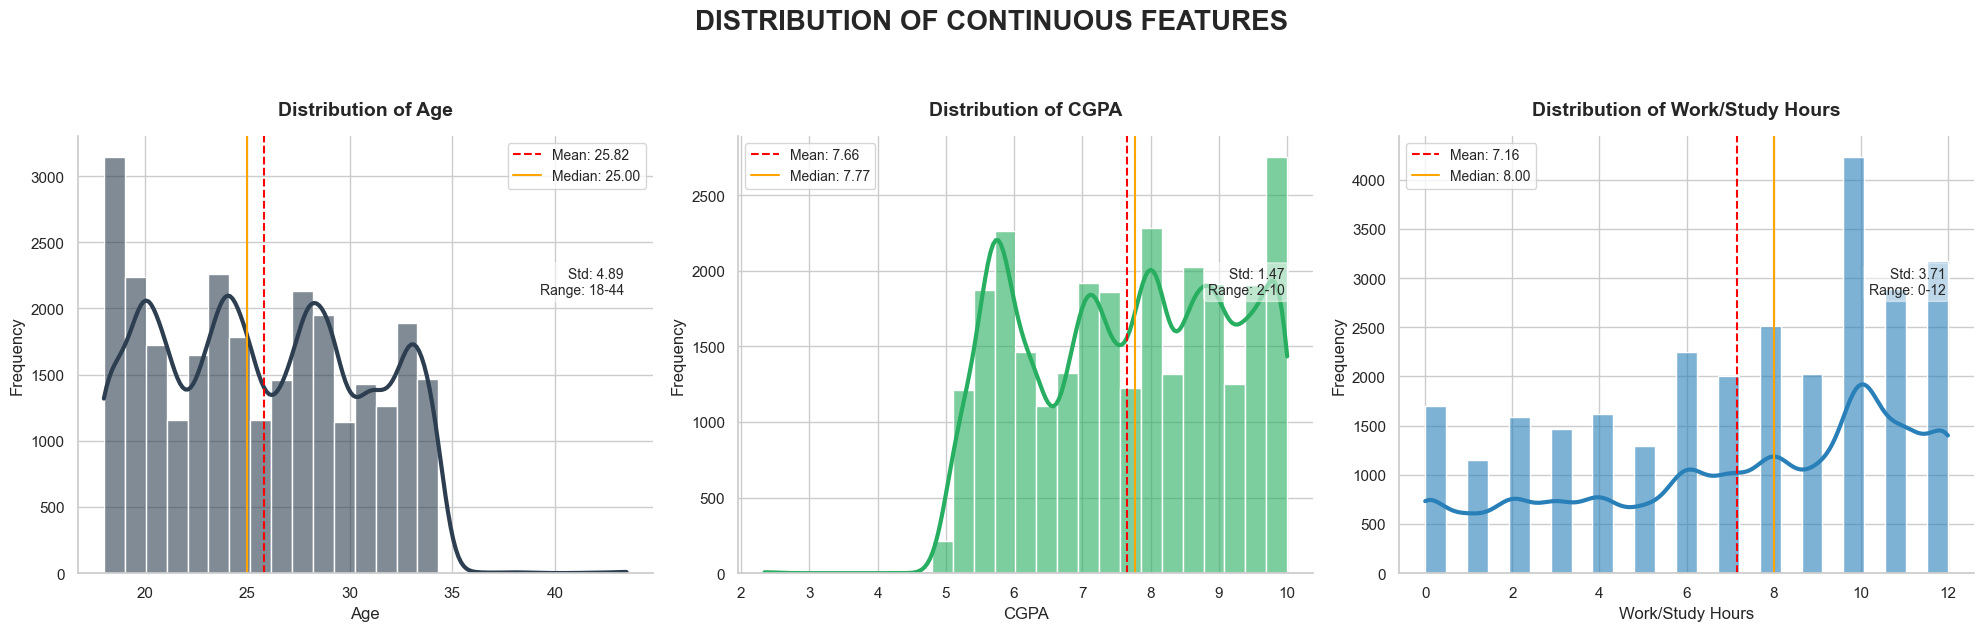

In [69]:

# Setup aesthetics
sns.set_theme(style="whitegrid")
continuous_features = ['Age', 'CGPA', 'Work/Study Hours']
colors = ['#2c3e50', '#27ae60', '#2980b9']

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
plt.suptitle("DISTRIBUTION OF CONTINUOUS FEATURES", fontsize=20, fontweight='bold', y=1.05)

for i, feature in enumerate(continuous_features):
    data = df_clean[feature].dropna()

    # Create Histogram with KDE
    sns.histplot(data, kde=True, ax=axes[i], color=colors[i], bins=25, alpha=0.6, line_kws={'linewidth': 3})

    # Add Mean and Median Lines
    mean_val = data.mean()
    median_val = data.median()
    axes[i].axvline(mean_val, color='red', linestyle='--', label=f'Mean: {mean_val:.2f}')
    axes[i].axvline(median_val, color='orange', linestyle='-', label=f'Median: {median_val:.2f}')

    # Styling
    axes[i].set_title(f'Distribution of {feature}', fontsize=14, fontweight='bold', pad=15)
    axes[i].set_xlabel(feature, fontsize=12)
    axes[i].set_ylabel('Frequency', fontsize=12)
    axes[i].legend(fontsize=10)

    # Stats Annotation Box
    stats_text = f"Std: {data.std():.2f}\nRange: {data.min():.0f}-{data.max():.0f}"
    axes[i].text(0.95, 0.70, stats_text, transform=axes[i].transAxes, fontsize=10,
                 verticalalignment='top', horizontalalignment='right',
                 bbox=dict(boxstyle='round', facecolor='white', alpha=0.5))

sns.despine()
plt.tight_layout()
plt.show()

### 5.2.1 Numerical Features vs Depression (Box Plots)


5.2.1 NUMERICAL FEATURES vs DEPRESSION - BOX PLOTS

 Comparing mean values by depression status:
Feature                             No Dep Mean     Dep Mean        Difference     
--------------------------------------------------------------------------------
Age                                 27.1357         24.8873         -2.2484        
Academic Pressure                   2.3616          3.6931          1.3315         
Work Pressure                       0.0006          0.0003          -0.0003        
CGPA                                7.6183          7.6842          0.0659         
Study Satisfaction                  3.2156          2.7515          -0.4641        
Job Satisfaction                    0.0009          0.0006          -0.0003        
Work/Study Hours                    6.2380          7.8076          1.5696         
Financial Stress                    2.5188          3.5795          1.0607         


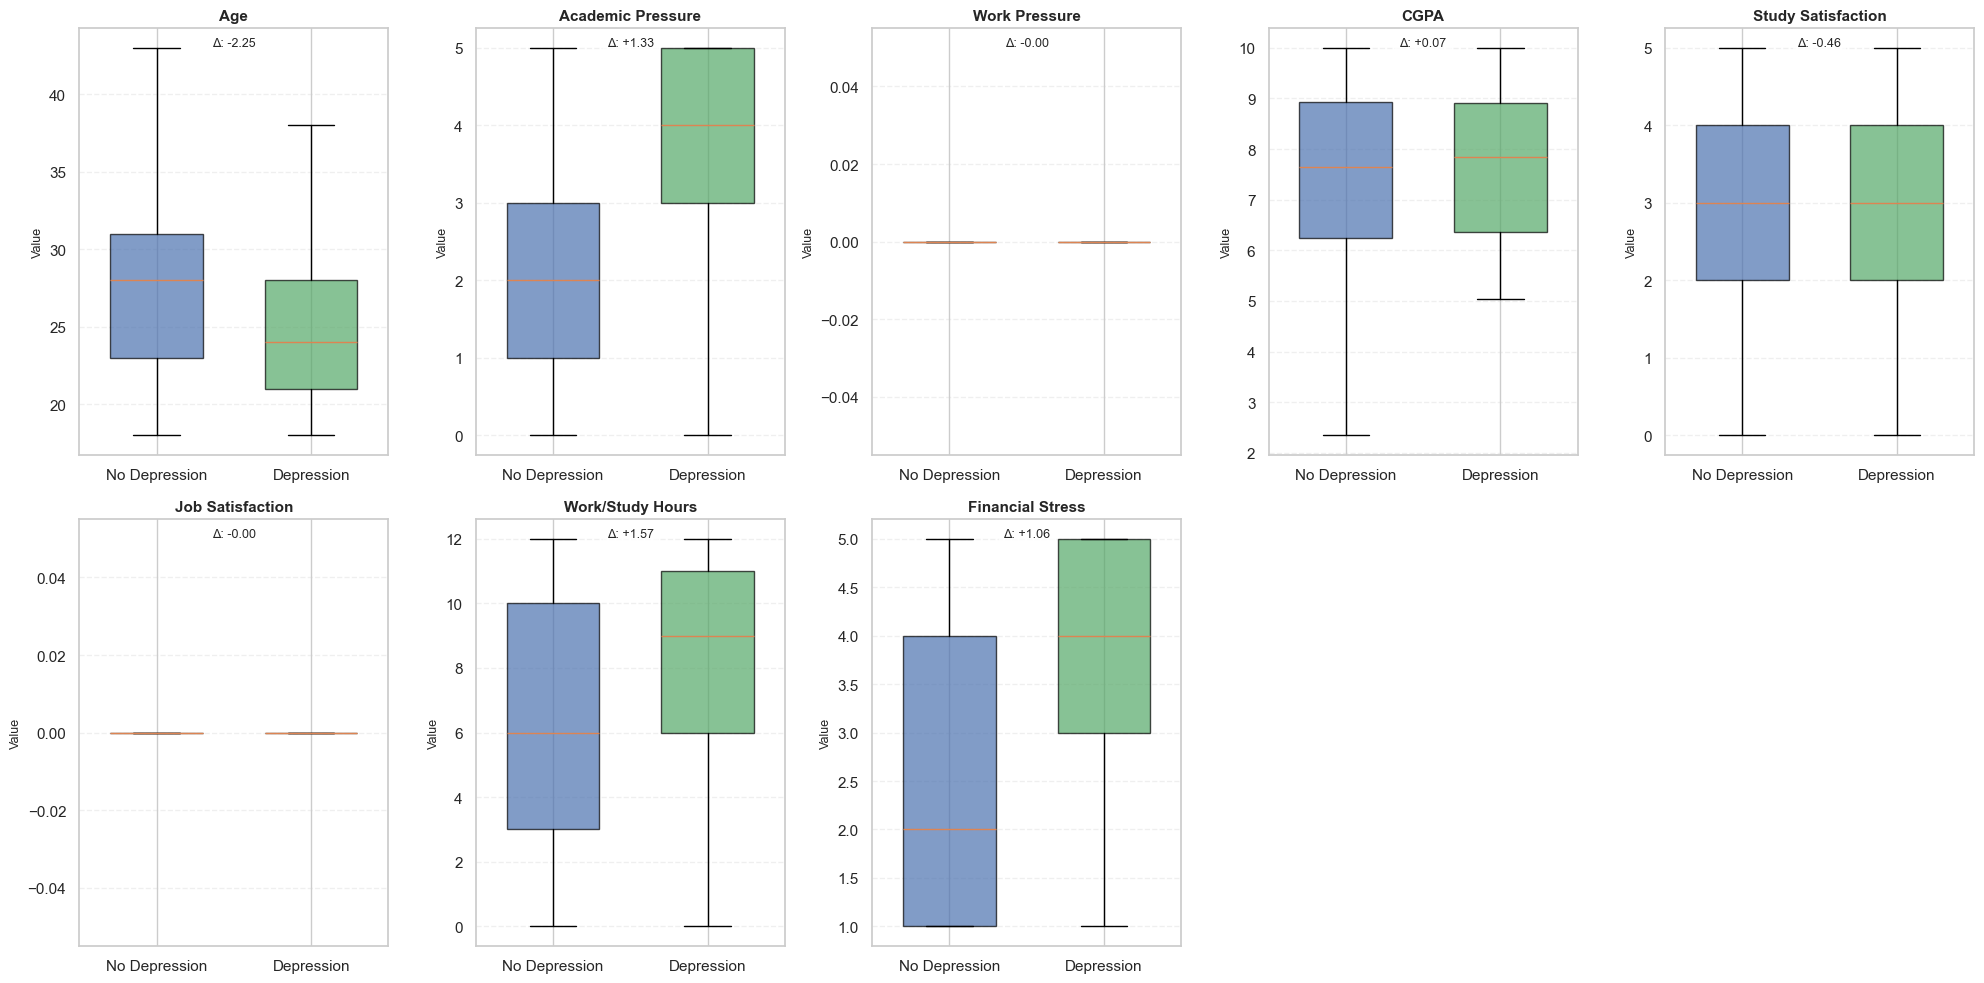


 Numerical features vs depression visualization saved!


In [70]:
print("\n" + "="*80)
print("5.2.1 NUMERICAL FEATURES vs DEPRESSION - BOX PLOTS")
print("="*80)

fig, axes = plt.subplots(2, 5, figsize=(20, 10))
axes = axes.flatten()

depression_labels = {0: 'No Depression', 1: 'Depression'}

print("\n Comparing mean values by depression status:")
print(f"{'Feature':<35} {'No Dep Mean':<15} {'Dep Mean':<15} {'Difference':<15}")
print("-"*80)

for idx, feature in enumerate(numerical_features):
    ax = axes[idx]

    # Prepare data
    no_dep = df_clean[df_clean['Depression'] == 0][feature]
    dep = df_clean[df_clean['Depression'] == 1][feature]

    # Create box plot
    bp = ax.boxplot([no_dep, dep], labels=['No Depression', 'Depression'],
                    patch_artist=True, widths=0.6, showfliers=False)

    # Customize colors
    colors = ['#4C72B0', '#55A868']
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)

    ax.set_title(f'{feature}', fontsize=11, fontweight='bold')
    ax.set_ylabel('Value', fontsize=9)
    ax.grid(axis='y', alpha=0.3, linestyle='--')

    # Statistics
    mean_no_dep = no_dep.mean()
    mean_dep = dep.mean()
    diff = mean_dep - mean_no_dep

    print(f"{feature:<35} {mean_no_dep:<15.4f} {mean_dep:<15.4f} {diff:<15.4f}")

    # Add text annotation
    ax.text(0.5, 0.98, f'Δ: {diff:+.2f}', transform=ax.transAxes, fontsize=9,
            verticalalignment='top', horizontalalignment='center',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# Remove extra plots
for i in range(idx + 1, len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.savefig('eda_5_2_1_numerical_vs_depression.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n Numerical features vs depression visualization saved!")

### 5.2.4 Ordinal Features vs Depression (Grouped Bar Charts)

## 5.3 Correlation Analysis

**Purpose**: Examine linear relationships between features and depression.

Correlation coefficients reveal:
- **Strong (+)**: Feature increases → Depression likely increases
- **Strong (−)**: Feature increases → Depression likely decreases
- **Weak**: Little linear relationship


5.3 CORRELATION ANALYSIS

 CORRELATION WITH DEPRESSION (Numeric Features Only, Ranked):
--------------------------------------------------------------------------------
Feature                                  Correlation     Strength       
--------------------------------------------------------------------------------
NOTE: Categorical (binary and ordinal) features excluded from Pearson correlation.
      Statistical significance tested in Section 6 using appropriate tests.

Academic Pressure                        0.4748          Moderate ↑
Financial Stress                         0.3636          Moderate ↑
Work/Study Hours                         0.2086          Weak ↑
CGPA                                     0.0221          Very Weak ↑
Work Pressure                            -0.0034         Very Weak ↓
Job Satisfaction                         -0.0035         Very Weak ↓
Study Satisfaction                       -0.1680         Weak ↓
Age                                      -0.2

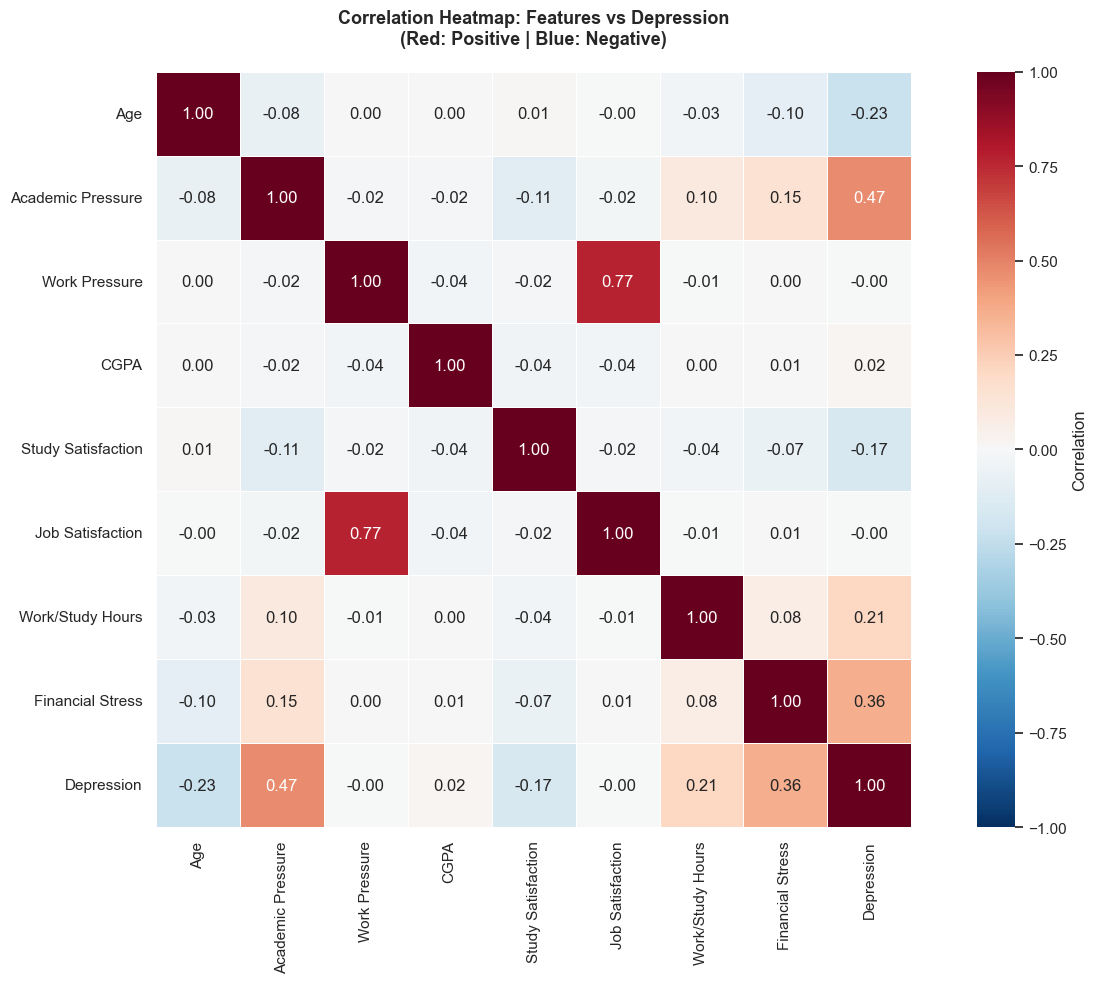


--------------------------------------------------------------------------------
🔝 TOP 8 FEATURES CORRELATED WITH DEPRESSION:
--------------------------------------------------------------------------------
  1. Academic Pressure                         0.4748  (increases depression ↑)
  2. Financial Stress                          0.3636  (increases depression ↑)
  3. Age                                      -0.2264  (decreases depression ↓)
  4. Work/Study Hours                          0.2086  (increases depression ↑)
  5. Study Satisfaction                       -0.1680  (decreases depression ↓)
  6. CGPA                                      0.0221  (increases depression ↑)
  7. Job Satisfaction                         -0.0035  (decreases depression ↓)
  8. Work Pressure                            -0.0034  (decreases depression ↓)

 Correlation analysis saved!


In [71]:
print("\n" + "="*80)
print("5.3 CORRELATION ANALYSIS")
print("="*80)

# Prepare data for correlation (numeric features only - categorical features excluded)
correlation_features = numerical_features + ['Depression']
df_correlation = df_clean[correlation_features].copy()

# Calculate Pearson correlation
correlation_matrix = df_correlation.corr()
depression_corr = correlation_matrix['Depression'].sort_values(ascending=False)

# Print results
print("\n CORRELATION WITH DEPRESSION (Numeric Features Only, Ranked):")
print("-"*80)
print(f"{'Feature':<40} {'Correlation':<15} {'Strength':<15}")
print("-"*80)
print("NOTE: Categorical (binary and ordinal) features excluded from Pearson correlation.")
print("      Statistical significance tested in Section 6 using appropriate tests.\n")

for feature, corr in depression_corr.items():
    if feature == 'Depression':
        continue

    abs_corr = abs(corr)
    if abs_corr < 0.1:
        strength = "Very Weak"
    elif abs_corr < 0.3:
        strength = "Weak"
    elif abs_corr < 0.5:
        strength = "Moderate"
    elif abs_corr < 0.7:
        strength = "Strong"
    else:
        strength = "Very Strong"

    direction = "↑" if corr > 0 else "↓"
    print(f"{feature:<40} {corr:<15.4f} {strength} {direction}")

# Visualization: Correlation Heatmap
print("\n🎨 Generating correlation heatmap...")

fig, ax = plt.subplots(figsize=(14, 10))

# Create heatmap
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            square=True, ax=ax, cbar_kws={'label': 'Correlation'}, linewidths=0.5,
            vmin=-1, vmax=1)

ax.set_title('Correlation Heatmap: Features vs Depression\n(Red: Positive | Blue: Negative)',
             fontsize=13, fontweight='bold', pad=20)

plt.tight_layout()
plt.savefig('eda_5_3_correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

# Top correlations
print("\n" + "-"*80)
print("🔝 TOP 8 FEATURES CORRELATED WITH DEPRESSION:")
print("-"*80)
top_corr = depression_corr.drop('Depression').abs().nlargest(8)
for i, feature in enumerate(top_corr.index, 1):
    corr_val = depression_corr[feature]
    direction = "increases depression ↑" if corr_val > 0 else "decreases depression ↓"
    print(f"  {i}. {feature:<40} {corr_val:>7.4f}  ({direction})")

print("\n Correlation analysis saved!")

## 5.4 EDA Summary & Key Insights

### Data Overview
- **Total Students**: 27,901 records
- **Depression Prevalence**: 58.55% (16,330 depressed / 11,571 non-depressed)
- **Features Analyzed**: 8 numerical + 3 binary + 2 ordinal + 3 categorical
- **Data Quality**: No missing values, no duplicate records, all features properly cleaned

### Key Findings

**Univariate Insights:**
1. Numerical features (8) show varied distributions - Age bell-shaped, Pressure/Satisfaction heavily skewed
2. Binary features relatively balanced except for rare suicidal thoughts (36% Yes)
3. Ordinal features show strong patterns - 77% sleep 7-8 hours, 53% moderate dietary habits
4. Categorical features dominated by few top categories (City, Profession, Degree)
5. All features properly cleaned and validate ranges

**Bivariate Insights:**
1. **Suicidal thoughts** is the strongest predictor: 79.05% depression rate (Yes) vs 23.22% (No) - 55.8% gap
2. Depressed and non-depressed students show **significant differences** in all numerical metrics
3. **Gender** shows minimal association: 58.45% (Female) vs 58.63% (Male) depression - nearly identical
4. **Family history** shows modest effect: 61.27% depression (Yes) vs 56.00% (No)
5. Categorical features reveal **high-risk groups** - some cities/professions reach 60%+ depression rates

**Correlation Insights:**
1. Numerical features show **moderate correlations** with depression
2. Positive correlations: Academic Pressure, Work Pressure, Financial Stress
3. Negative correlations: CGPA, Study Satisfaction, Job Satisfaction
4. Overall high baseline depression rate (58.55%) indicates widespread student mental health concerns
5. Multiple risk factors compound to create elevated depression prevalence

# Section 6: Hypothesis Testing & Statistical Analysis

## Objective
Identify which **features** have **statistically significant** associations with depression.

**Approach:**
- **Numerical features**: Independent samples t-test (compare means)
- **Binary features**: Chi-square test (check independence)
- **Significance level**: α = 0.05
- **Effect size**: Cohen's d (t-test) and Cramér's V (chi-square)

### 6.1 Import Statistical Libraries

In [72]:
from scipy.stats import ttest_ind, chi2_contingency

# Effect size functions
def cohens_d(group0, group1):
    """Cohen's d for t-test"""
    n0, n1 = len(group0), len(group1)
    var0, var1 = group0.var(), group1.var()
    pooled_std = np.sqrt(((n0-1)*var0 + (n1-1)*var1) / (n0 + n1 - 2))
    return (group0.mean() - group1.mean()) / pooled_std

def cramers_v(contingency):
    """Cramér's V for chi-square"""
    chi2 = chi2_contingency(contingency)[0]
    n = contingency.sum()
    min_dim = min(contingency.shape) - 1
    return np.sqrt(chi2 / (n * min_dim)) if min_dim > 0 else 0

print("Statistical libraries imported")

Statistical libraries imported


### 6.2 T-Test: Numerical Features vs Depression

**Test**: Independent samples t-test  
**H₀ (Null)**: Mean values are equal between depression groups  
**H₁ (Alt)**: Mean values differ between depression groups  
**Significant if**: p-value < 0.05

In [73]:
print("\n" + "="*90)
print("6.2 INDEPENDENT T-TEST: NUMERICAL FEATURES vs DEPRESSION")
print("="*90)

t_test_results = []

print(f"\n{'Feature':<35} {'p-value':<12} {'Significant':<12} {'Cohen\'s d':<12} {'Effect':<12}")
print("-"*90)

for feature in numerical_features:
    no_dep = df_clean[df_clean['Depression'] == 0][feature].dropna()
    dep = df_clean[df_clean['Depression'] == 1][feature].dropna()

    # T-test
    t_stat, p_value = ttest_ind(no_dep, dep)
    d = cohens_d(no_dep, dep)

    significant = "Yes ✓" if p_value < 0.05 else "No"

    # Effect size interpretation
    abs_d = abs(d)
    if abs_d < 0.2:
        effect = "Negligible"
    elif abs_d < 0.5:
        effect = "Small"
    elif abs_d < 0.8:
        effect = "Medium"
    else:
        effect = "Large"

    print(f"{feature:<35} {p_value:<12.2e} {significant:<12} {d:<12.4f} {effect:<12}")

    t_test_results.append({
        'Feature': feature,
        'p_value': p_value,
        'significant': p_value < 0.05,
        'cohens_d': d
    })

# Summary
sig_features = [r for r in t_test_results if r['significant']]
print(f"\nSignificant features: {len(sig_features)}/{len(numerical_features)}")
print("✓ Features with significant differences between depression groups:")

for r in sorted(sig_features, key=lambda x: x['p_value']):
    print(f"  • {r['Feature']:<40} p={r['p_value']:.2e} | d={r['cohens_d']:.4f}")


6.2 INDEPENDENT T-TEST: NUMERICAL FEATURES vs DEPRESSION

Feature                             p-value      Significant  Cohen's d    Effect      
------------------------------------------------------------------------------------------
Age                                 0.00e+00     Yes ✓        0.4719       Small       
Academic Pressure                   0.00e+00     Yes ✓        -1.0952      Large       
Work Pressure                       5.76e-01     No           0.0068       Negligible  
CGPA                                2.21e-04     Yes ✓        -0.0449      Negligible  
Study Satisfaction                  1.17e-175    Yes ✓        0.3459       Small       
Job Satisfaction                    5.61e-01     No           0.0071       Negligible  
Work/Study Hours                    8.60e-272    Yes ✓        -0.4329      Small       
Financial Stress                    0.00e+00     Yes ✓        -0.7922      Medium      

Significant features: 6/8
✓ Features with significant dif

### 6.4 Summary of Significant Features

**What it means:**
- ✓ **Significant** (p < 0.05): Strong statistical evidence feature differs by depression status
- ✗ **Not significant** (p ≥ 0.05): Insufficient evidence to reject null hypothesis

**Effect Size:**
- **Cohen's d** (t-test): >0.8 is large effect
- **Cramér's V** (chi-square): >0.3 is moderate effect

# Section 7: Feature Engineering & Preprocessing for Machine Learning

## Objective
Prepare cleaned data for model training by removing non-predictive features, encoding Degree, and creating train/test datasets ready for Random Forest & Logistic Regression.

## Strategy
1. Remove non-predictive features (5 features)
2. Encode Degree using group encoding (28 → 5 groups)
3. Verify data quality
4. Create features (X) and target (y)
5. Split into train/test sets (80/20, stratified)
6. Scale features for Logistic Regression

### 7.1 Drop Non-Predictive Features

This branch of work is going to be focused on academic features gathered in this dataset, therefore, features that are no related to academic factors are going to be dropped.

In [74]:
print("="*80)
print("7.1 DROP NON-PREDICTIVE FEATURES")
print("="*80)

df_model = df_clean.copy()

columns_to_keep = [
    "Academic Pressure",
    "Work/Study Hours",
    "CGPA",
    "Study Satisfaction",
    "Depression"
]

df_model = df_model[columns_to_keep]

print(f"\n✓ Dataset shape: {df_model.shape}")
print(f"✓ Remaining features: {df_model.shape[1] - 1} predictors + 1 target")
print(f"✓ Feature list: {list(df_model.columns)}")

7.1 DROP NON-PREDICTIVE FEATURES

✓ Dataset shape: (27901, 5)
✓ Remaining features: 4 predictors + 1 target
✓ Feature list: ['Academic Pressure', 'Work/Study Hours', 'CGPA', 'Study Satisfaction', 'Depression']


### 7.3 Verify Final Features

**Objective**: Quality assurance after feature removal and encoding

**Checks**:
1. No missing values in dataset
2. Correct data types for all columns
3. Verify final feature count and list

In [75]:
print("\n" + "="*80)
print("7.3 VERIFY FINAL FEATURES")
print("="*80)

# Check for missing values
print("\n[1] Missing Values Check:")
missing = df_model.isnull().sum()
if missing.sum() == 0:
    print("  ✓ No missing values detected")
else:
    print(f"  ⚠ Found {missing.sum()} missing values:")
    print(missing[missing > 0])

# Check data types
print("\n[2] Data Types:")
print(df_model.dtypes)

# Verify final features
print("\n[3] Final Feature Summary:")
features = [col for col in df_model.columns if col != 'Depression']
print(f"  • Target variable: Depression")
print(f"  • Predictor variables: {len(features)}")
print(f"  • Features: {features}")
print(f"  • Dataset shape: {df_model.shape}")

# Show summary statistics
print("\n[4] Dataset Summary:")
print(df_model.describe())


7.3 VERIFY FINAL FEATURES

[1] Missing Values Check:
  ✓ No missing values detected

[2] Data Types:
Academic Pressure     float64
Work/Study Hours      float64
CGPA                  float64
Study Satisfaction    float64
Depression              int64
dtype: object

[3] Final Feature Summary:
  • Target variable: Depression
  • Predictor variables: 4
  • Features: ['Academic Pressure', 'Work/Study Hours', 'CGPA', 'Study Satisfaction']
  • Dataset shape: (27901, 5)

[4] Dataset Summary:
       Academic Pressure  Work/Study Hours          CGPA  Study Satisfaction  \
count       27901.000000      27901.000000  27901.000000        27901.000000   
mean            3.141214          7.156984      7.656861            2.943837   
std             1.381465          3.707642      1.467369            1.361148   
min             0.000000          0.000000      2.345000            0.000000   
25%             2.000000          4.000000      6.290000            2.000000   
50%             3.000000     

### 7.4 Create Features (X) and Target (y)

**Objective**: Separate predictors from the target variable

**Process**:
- X: All columns except 'Depression'
- y: 'Depression' column only
- Verify shapes and class distribution

In [76]:
print("\n" + "="*80)
print("7.4 CREATE FEATURES (X) AND TARGET (y)")
print("="*80)

# Separate features and target
X = df_model.drop('Depression', axis=1)
y = df_model['Depression']

print(f"\nFeatures Matrix (X):")
print(f"  • Shape: {X.shape}")
print(f"  • Columns ({X.shape[1]}): {list(X.columns)}")

print(f"\nTarget Vector (y):")
print(f"  • Shape: {y.shape}")
print(f"  • Data type: {y.dtype}")
print(f"  • Value counts:")
print(y.value_counts().sort_index())

# Show class distribution (%)
print(f"\nClass Distribution:")
class_dist = y.value_counts(normalize=True).sort_index() * 100
for label, pct in class_dist.items():
    print(f"  • No Depression (0): {class_dist[0]:.2f}%" if label == 0 else f"  • Depression (1): {class_dist[1]:.2f}%")


7.4 CREATE FEATURES (X) AND TARGET (y)

Features Matrix (X):
  • Shape: (27901, 4)
  • Columns (4): ['Academic Pressure', 'Work/Study Hours', 'CGPA', 'Study Satisfaction']

Target Vector (y):
  • Shape: (27901,)
  • Data type: int64
  • Value counts:
Depression
0    11565
1    16336
Name: count, dtype: int64

Class Distribution:
  • No Depression (0): 41.45%
  • Depression (1): 58.55%


### 7.5 Train-Test Split (Stratified 80-20)

**Objective**: Split data into training and testing sets with class balance preservation

**Strategy**:
- **80% Training** (22,320 samples): For model fitting
- **20% Testing** (5,581 samples): For unbiased evaluation
- **Stratified**: Both train and test maintain ~43% depression rate
- **Random state**: Fixed at 42 for reproducibility

In [77]:
from sklearn.model_selection import train_test_split

print("\n" + "="*80)
print("7.5 TRAIN-TEST SPLIT (STRATIFIED 80-20)")
print("="*80)

# Stratified train-test split (preserves class distribution)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,           # 20% test, 80% train
    random_state=42,         # Reproducibility
    stratify=y               # Maintain class balance
)

print(f"\n[Train Set]")
print(f"  • Shape: {X_train.shape}")
print(f"  • Depression distribution:")
print(f"    - No Depression (0): {(y_train == 0).sum()} ({(y_train == 0).mean() * 100:.2f}%)")
print(f"    - Depression (1): {(y_train == 1).sum()} ({(y_train == 1).mean() * 100:.2f}%)")

print(f"\n[Test Set]")
print(f"  • Shape: {X_test.shape}")
print(f"  • Depression distribution:")
print(f"    - No Depression (0): {(y_test == 0).sum()} ({(y_test == 0).mean() * 100:.2f}%)")
print(f"    - Depression (1): {(y_test == 1).sum()} ({(y_test == 1).mean() * 100:.2f}%)")

print(f"\n✓ Stratified split successful - class distribution preserved!")


7.5 TRAIN-TEST SPLIT (STRATIFIED 80-20)

[Train Set]
  • Shape: (22320, 4)
  • Depression distribution:
    - No Depression (0): 9252 (41.45%)
    - Depression (1): 13068 (58.55%)

[Test Set]
  • Shape: (5581, 4)
  • Depression distribution:
    - No Depression (0): 2313 (41.44%)
    - Depression (1): 3268 (58.56%)

✓ Stratified split successful - class distribution preserved!


### 7.6 Feature Scaling (StandardScaler)

**Objective**: Normalize features for distance-based models (Logistic Regression)

**Important Notes**:
- Fit scaler **only on training data** to prevent data leakage
- Transform training and test data using training statistics
- **Random Forest** does not require scaling (tree-based)
- **Logistic Regression** requires scaling (distance-based)

In [78]:
from sklearn.preprocessing import StandardScaler

print("\n" + "="*80)
print("7.6 FEATURE SCALING (STANDARDSCALER)")
print("="*80)

# Initialize scaler
scaler = StandardScaler()

# Fit ONLY on training data (prevent data leakage)
print("\n[1] Fit scaler on training data:")
scaler.fit(X_train)
print(f"  ✓ Scaler fitted on {X_train.shape[0]} training samples")

# Transform both train and test using training statistics
print("\n[2] Transform data using training statistics:")
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)
print(f"  ✓ Training set transformed: {X_train_scaled.shape}")
print(f"  ✓ Test set transformed: {X_test_scaled.shape}")

# Convert to DataFrames for easier handling
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X.columns, index=X_test.index)

print("\n[3] Verification - Feature ranges AFTER scaling (Training Set):")
print("-" * 80)
for col in X_train_scaled.columns[:5]:  # Show first 5 features
    print(f"{col:<35} Mean: {X_train_scaled[col].mean():>10.6f}  Std: {X_train_scaled[col].std():>10.6f}")
print("  ...")

print("\n✓ Feature scaling completed!")
print(f"  • Unscaled data ready for Random Forest: X_train, X_test")
print(f"  • Scaled data ready for Logistic Regression: X_train_scaled, X_test_scaled")


7.6 FEATURE SCALING (STANDARDSCALER)

[1] Fit scaler on training data:
  ✓ Scaler fitted on 22320 training samples

[2] Transform data using training statistics:
  ✓ Training set transformed: (22320, 4)
  ✓ Test set transformed: (5581, 4)

[3] Verification - Feature ranges AFTER scaling (Training Set):
--------------------------------------------------------------------------------
Academic Pressure                   Mean:  -0.000000  Std:   1.000022
Work/Study Hours                    Mean:   0.000000  Std:   1.000022
CGPA                                Mean:   0.000000  Std:   1.000022
Study Satisfaction                  Mean:  -0.000000  Std:   1.000022
  ...

✓ Feature scaling completed!
  • Unscaled data ready for Random Forest: X_train, X_test
  • Scaled data ready for Logistic Regression: X_train_scaled, X_test_scaled


# Section 8: Model Preparation & Training

### 8.1 Overview
**Objective**: Build and train two classification models to predict student depression.

**Models Selected**:
1. **Random Forest Classifier**
   - Ensemble method (100 decision trees)
   - Handles non-linear relationships
   - Provides feature importance scores
   - Robust to outliers
   
2. **Logistic Regression**
   - Linear classification model
   - Interpretable (coefficients show feature impact)
   - Fast training
   - Baseline for comparison

**Strategy**:
- Train both models on training data
- Evaluate on test data
- Compare performance metrics
- Analyze feature importance (Random Forest) and coefficients (Logistic Regression)

### 8.2 Import ML Libraries

Import all necessary libraries for model training and evaluation

In [79]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, confusion_matrix, classification_report,
                             roc_curve, auc)
import matplotlib.pyplot as plt

print("="*80)
print("8.2 MACHINE LEARNING LIBRARIES IMPORTED")
print("="*80)
print("\n✓ Models: RandomForestClassifier, LogisticRegression")
print("✓ Metrics: Accuracy, Precision, Recall, F1-Score, ROC-AUC")
print("✓ Evaluation: Confusion Matrix, Classification Report, ROC Curve")

8.2 MACHINE LEARNING LIBRARIES IMPORTED

✓ Models: RandomForestClassifier, LogisticRegression
✓ Metrics: Accuracy, Precision, Recall, F1-Score, ROC-AUC
✓ Evaluation: Confusion Matrix, Classification Report, ROC Curve


### 8.3 Train Random Forest Classifier

**Why Random Forest?**
- Ensemble method (combines multiple decision trees)
- Handles non-linear relationships well
- Robust to outliers
- Provides feature importance scores
- Does not require feature scaling

In [80]:
from sklearn.model_selection import GridSearchCV

print("\n" + "="*80)
print("8.4 HYPERPARAMETER TUNING - RANDOM FOREST")
print("="*80)

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [5, 8, 12],
    'min_samples_split': [10, 20],
    'min_samples_leaf': [5, 10],
    'max_features': ['sqrt', 'log2'],
    'class_weight': ['balanced']
}

grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42, n_jobs=-1),
    param_grid=param_grid,
    cv=5,
    scoring='roc_auc',
    verbose=1
)

print("\n[1] Starting Grid Search (this may take a few minutes)...")
grid_search.fit(X_train, y_train)


rf_model = grid_search.best_estimator_

print(f"\n[2] Best Parameters Found:")
print(grid_search.best_params_)



8.4 HYPERPARAMETER TUNING - RANDOM FOREST

[1] Starting Grid Search (this may take a few minutes)...
Fitting 5 folds for each of 48 candidates, totalling 240 fits

[2] Best Parameters Found:
{'class_weight': 'balanced', 'max_depth': 5, 'max_features': 'sqrt', 'min_samples_leaf': 10, 'min_samples_split': 10, 'n_estimators': 200}


In [81]:

# Make predictions
print("\n[3] Making predictions on train and test sets...")
rf_train_pred = rf_model.predict(X_train)
rf_test_pred = rf_model.predict(X_test)
rf_train_proba = rf_model.predict_proba(X_train)[:, 1]
rf_test_proba = rf_model.predict_proba(X_test)[:, 1]
print("    ✓ Predictions complete!")

# Calculate metrics
rf_train_acc = accuracy_score(y_train, rf_train_pred)
rf_test_acc = accuracy_score(y_test, rf_test_pred)
rf_train_auc = roc_auc_score(y_train, rf_train_proba)
rf_test_auc = roc_auc_score(y_test, rf_test_proba)

print("\n[4] Random Forest Performance:")
print(f"    • Training Accuracy:   {rf_train_acc:.4f} ({rf_train_acc*100:.2f}%)")
print(f"    • Test Accuracy:       {rf_test_acc:.4f} ({rf_test_acc*100:.2f}%)")
print(f"    • Training ROC-AUC:    {rf_train_auc:.4f}")
print(f"    • Test ROC-AUC:        {rf_test_auc:.4f}")
print(f"    • The Gap:              {abs(rf_train_auc - rf_test_auc):.4f}")

# Classification report
print("\n[5] Detailed Test Set Report:")
print(classification_report(y_test, rf_test_pred, target_names=['No Depression', 'Depression']))


[3] Making predictions on train and test sets...
    ✓ Predictions complete!

[4] Random Forest Performance:
    • Training Accuracy:   0.7390 (73.90%)
    • Test Accuracy:       0.7388 (73.88%)
    • Training ROC-AUC:    0.8066
    • Test ROC-AUC:        0.7976
    • The Gap:              0.0089

[5] Detailed Test Set Report:
               precision    recall  f1-score   support

No Depression       0.68      0.69      0.69      2313
   Depression       0.78      0.77      0.78      3268

     accuracy                           0.74      5581
    macro avg       0.73      0.73      0.73      5581
 weighted avg       0.74      0.74      0.74      5581



### 8.4 Train Logistic Regression

**Why Logistic Regression?**
- Linear classification model (interpretable)
- Fast training and prediction
- Provides coefficients showing feature impact
- Good baseline for comparison
- Requires feature scaling for optimal performance

**Configuration**:
- `max_iter=1000`: Max iterations for convergence
- `random_state=42`: Reproducibility
- `solver='lbfgs'`: Good for small-medium datasets
- `class_weight='balanced'`: Handle class imbalance
- `C=1.0`: Regularization strength

In [82]:
print("\n" + "="*80)
print("8.4 LOGISTIC REGRESSION - TRAINING")
print("="*80)

# Initialize Logistic Regression
lr_model = LogisticRegression(
    max_iter=1000,
    random_state=42,
    solver='lbfgs',
    class_weight='balanced',
    C=1.0
)

print("\n[1] Model initialized with parameters:")
print(f"    • solver: lbfgs")
print(f"    • max_iter: 1000")
print(f"    • class_weight: balanced")

# Train on SCALED data (Logistic Regression requires scaling)
print("\n[2] Training on scaled data...")
lr_model.fit(X_train_scaled, y_train)
print("    ✓ Training complete!")

# Make predictions
print("\n[3] Making predictions on train and test sets...")
lr_train_pred = lr_model.predict(X_train_scaled)
lr_test_pred = lr_model.predict(X_test_scaled)
lr_train_proba = lr_model.predict_proba(X_train_scaled)[:, 1]
lr_test_proba = lr_model.predict_proba(X_test_scaled)[:, 1]
print("    ✓ Predictions complete!")

# Calculate metrics
lr_train_acc = accuracy_score(y_train, lr_train_pred)
lr_test_acc = accuracy_score(y_test, lr_test_pred)
lr_train_auc = roc_auc_score(y_train, lr_train_proba)
lr_test_auc = roc_auc_score(y_test, lr_test_proba)

print("\n[4] Logistic Regression Performance:")
print(f"    • Training Accuracy:   {lr_train_acc:.4f} ({lr_train_acc*100:.2f}%)")
print(f"    • Test Accuracy:       {lr_test_acc:.4f} ({lr_test_acc*100:.2f}%)")
print(f"    • Training ROC-AUC:    {lr_train_auc:.4f}")
print(f"    • Test ROC-AUC:        {lr_test_auc:.4f}")

# Classification report
print("\n[5] Detailed Test Set Report:")
print(classification_report(y_test, lr_test_pred, target_names=['No Depression', 'Depression']))


8.4 LOGISTIC REGRESSION - TRAINING

[1] Model initialized with parameters:
    • solver: lbfgs
    • max_iter: 1000
    • class_weight: balanced

[2] Training on scaled data...
    ✓ Training complete!

[3] Making predictions on train and test sets...
    ✓ Predictions complete!

[4] Logistic Regression Performance:
    • Training Accuracy:   0.7301 (73.01%)
    • Test Accuracy:       0.7350 (73.50%)
    • Training ROC-AUC:    0.8031
    • Test ROC-AUC:        0.7986

[5] Detailed Test Set Report:
               precision    recall  f1-score   support

No Depression       0.66      0.73      0.70      2313
   Depression       0.80      0.74      0.76      3268

     accuracy                           0.73      5581
    macro avg       0.73      0.73      0.73      5581
 weighted avg       0.74      0.73      0.74      5581



### 8.5 Model Comparison & Evaluation

**Metrics Explained**:
- **Accuracy**: Overall correctness % = (TP + TN) / All
- **Precision**: Of predicted depressed students, how many actually are? = TP / (TP + FP)
- **Recall**: Of actual depressed students, how many were found? = TP / (TP + FN)
- **F1-Score**: Harmonic mean of Precision and Recall
- **ROC-AUC**: Area under receiver operating characteristic curve (0.5=random, 1.0=perfect)

**Which model is better?**
- Higher test accuracy = less overall errors
- Higher recall = identifies more at-risk students (better for screening)
- Higher precision = fewer false alarms (fewer unnecessary interventions)

In [83]:
print("\n" + "="*80)
print("8.5 MODEL COMPARISON & EVALUATION")
print("="*80)

# Create comparison dataframe
comparison_data = {
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC'],
    'Random Forest (Test)': [
        accuracy_score(y_test, rf_test_pred),
        precision_score(y_test, rf_test_pred),
        recall_score(y_test, rf_test_pred),
        f1_score(y_test, rf_test_pred),
        roc_auc_score(y_test, rf_test_proba)
    ],
    'Logistic Regression (Test)': [
        accuracy_score(y_test, lr_test_pred),
        precision_score(y_test, lr_test_pred),
        recall_score(y_test, lr_test_pred),
        f1_score(y_test, lr_test_pred),
        roc_auc_score(y_test, lr_test_proba)
    ]
}

comparison_df = pd.DataFrame(comparison_data)

print("\n MODEL PERFORMANCE COMPARISON:")
print("-"*80)
print(comparison_df.to_string(index=False))

# Determine best model
rf_avg = comparison_df['Random Forest (Test)'].mean()
lr_avg = comparison_df['Logistic Regression (Test)'].mean()
best_model = 'Random Forest' if rf_avg > lr_avg else 'Logistic Regression'

print("\n" + "="*80)
print(f"BEST MODEL: {best_model}")
print("="*80)
print(f"Random Forest Average Score:      {rf_avg:.4f}")
print(f"Logistic Regression Average Score: {lr_avg:.4f}")

# Confusion matrices
print("\n CONFUSION MATRICES:")
print("-"*80)
print("\nRandom Forest:")
rf_cm = confusion_matrix(y_test, rf_test_pred)
print(f"  True Negatives:  {rf_cm[0,0]:<6} | False Positives: {rf_cm[0,1]:<6}")
print(f"  False Negatives: {rf_cm[1,0]:<6} | True Positives:  {rf_cm[1,1]:<6}")

print("\nLogistic Regression:")
lr_cm = confusion_matrix(y_test, lr_test_pred)
print(f"  True Negatives:  {lr_cm[0,0]:<6} | False Positives: {lr_cm[0,1]:<6}")
print(f"  False Negatives: {lr_cm[1,0]:<6} | True Positives:  {lr_cm[1,1]:<6}")

print("\n✓ Both models trained and evaluated successfully!")


8.5 MODEL COMPARISON & EVALUATION

 MODEL PERFORMANCE COMPARISON:
--------------------------------------------------------------------------------
   Metric  Random Forest (Test)  Logistic Regression (Test)
 Accuracy              0.738756                    0.734994
Precision              0.780881                    0.795702
   Recall              0.769890                    0.736536
 F1-Score              0.775347                    0.764977
  ROC-AUC              0.797636                    0.798614

BEST MODEL: Random Forest
Random Forest Average Score:      0.7725
Logistic Regression Average Score: 0.7662

 CONFUSION MATRICES:
--------------------------------------------------------------------------------

Random Forest:
  True Negatives:  1607   | False Positives: 706   
  False Negatives: 752    | True Positives:  2516  

Logistic Regression:
  True Negatives:  1695   | False Positives: 618   
  False Negatives: 861    | True Positives:  2407  

✓ Both models trained and evalua

### 8.6 Feature Importance Analysis

**Random Forest Importance**: Based on how much each feature splits the data (higher = more important)

**Logistic Regression Coefficients**:
- Positive coefficients → increases depression risk
- Negative coefficients → decreases depression risk
- Larger magnitude → stronger effect

In [84]:
print("\n" + "="*80)
print("8.6 FEATURE IMPORTANCE ANALYSIS")
print("="*80)

# Random Forest Feature Importance
print("\n RANDOM FOREST FEATURE IMPORTANCE (Top 10):")
print("-"*80)
rf_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

for idx, (i, row) in enumerate(rf_importance.head(10).iterrows(), 1):
    bar = "█" * int(row['Importance'] * 100)
    print(f"{idx:2d}. {row['Feature']:<35} {bar} {row['Importance']:.4f}")

# Logistic Regression Coefficients
print("\n LOGISTIC REGRESSION COEFFICIENTS (Top 10 Risk Factors):")
print("-"*80)
lr_coef = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': lr_model.coef_[0]
}).sort_values('Coefficient', ascending=False)

print("\n  INCREASES Depression Risk (Positive):")
for idx, (i, row) in enumerate(lr_coef.head(5).iterrows(), 1):
    print(f"  {idx}. {row['Feature']:<35} {row['Coefficient']:>+.4f}")

print("\n  DECREASES Depression Risk (Negative):")
for idx, (i, row) in enumerate(lr_coef.tail(5).iterrows(), 1):
    print(f"  {idx}. {row['Feature']:<35} {row['Coefficient']:>+.4f}")

print("\n✓ Feature importance analysis complete!")


8.6 FEATURE IMPORTANCE ANALYSIS

 RANDOM FOREST FEATURE IMPORTANCE (Top 10):
--------------------------------------------------------------------------------
 1. Academic Pressure                   ████████████████████████████████████████████████████████████████████████████████ 0.8009
 2. Work/Study Hours                    ████████████ 0.1234
 3. Study Satisfaction                  ██████ 0.0647
 4. CGPA                                █ 0.0110

 LOGISTIC REGRESSION COEFFICIENTS (Top 10 Risk Factors):
--------------------------------------------------------------------------------

  INCREASES Depression Risk (Positive):
  1. Academic Pressure                   +1.1225
  2. Work/Study Hours                    +0.4283
  3. CGPA                                +0.0671
  4. Study Satisfaction                  -0.3106

  DECREASES Depression Risk (Negative):
  1. Academic Pressure                   +1.1225
  2. Work/Study Hours                    +0.4283
  3. CGPA                          


8.8 CONFUSION MATRICES COMPARISON


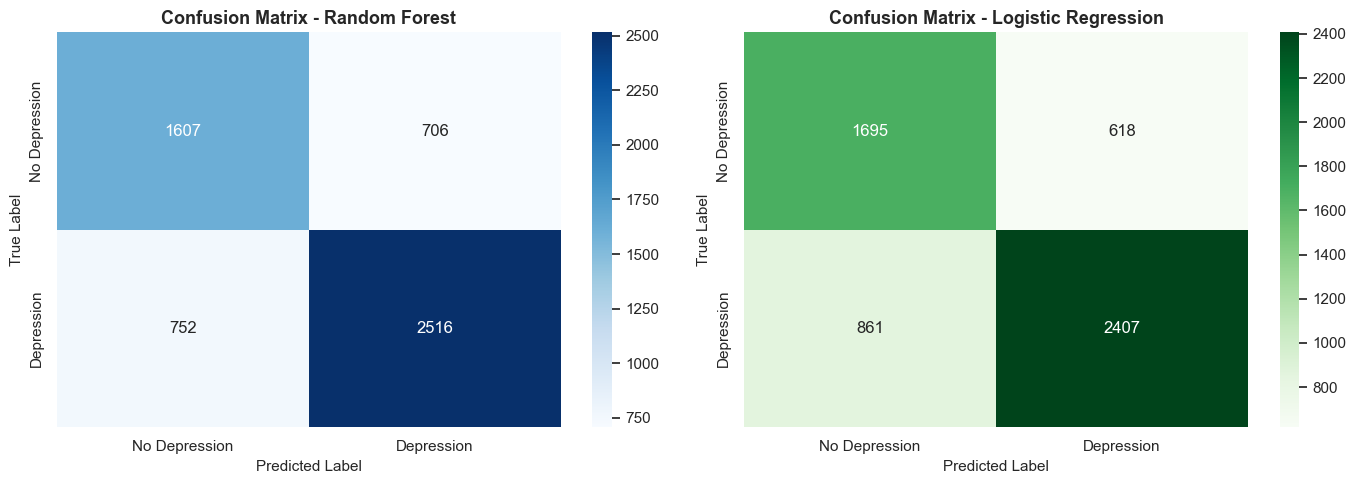

✓ Confusion matrices displayed!


In [85]:
print("\n" + "="*80)
print("8.8 CONFUSION MATRICES COMPARISON")
print("="*80)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Random Forest Confusion Matrix
ax = axes[0]
rf_cm = confusion_matrix(y_test, rf_test_pred)
sns.heatmap(rf_cm, annot=True, fmt='d', cmap='Blues', ax=ax, cbar=True,
            xticklabels=['No Depression', 'Depression'],
            yticklabels=['No Depression', 'Depression'])
ax.set_title('Confusion Matrix - Random Forest', fontweight='bold', fontsize=13)
ax.set_ylabel('True Label', fontsize=11)
ax.set_xlabel('Predicted Label', fontsize=11)

# Logistic Regression Confusion Matrix
ax = axes[1]
lr_cm = confusion_matrix(y_test, lr_test_pred)
sns.heatmap(lr_cm, annot=True, fmt='d', cmap='Greens', ax=ax, cbar=True,
            xticklabels=['No Depression', 'Depression'],
            yticklabels=['No Depression', 'Depression'])
ax.set_title('Confusion Matrix - Logistic Regression', fontweight='bold', fontsize=13)
ax.set_ylabel('True Label', fontsize=11)
ax.set_xlabel('Predicted Label', fontsize=11)

plt.tight_layout()
plt.show()

print("✓ Confusion matrices displayed!")



8.9 ROC CURVES COMPARISON


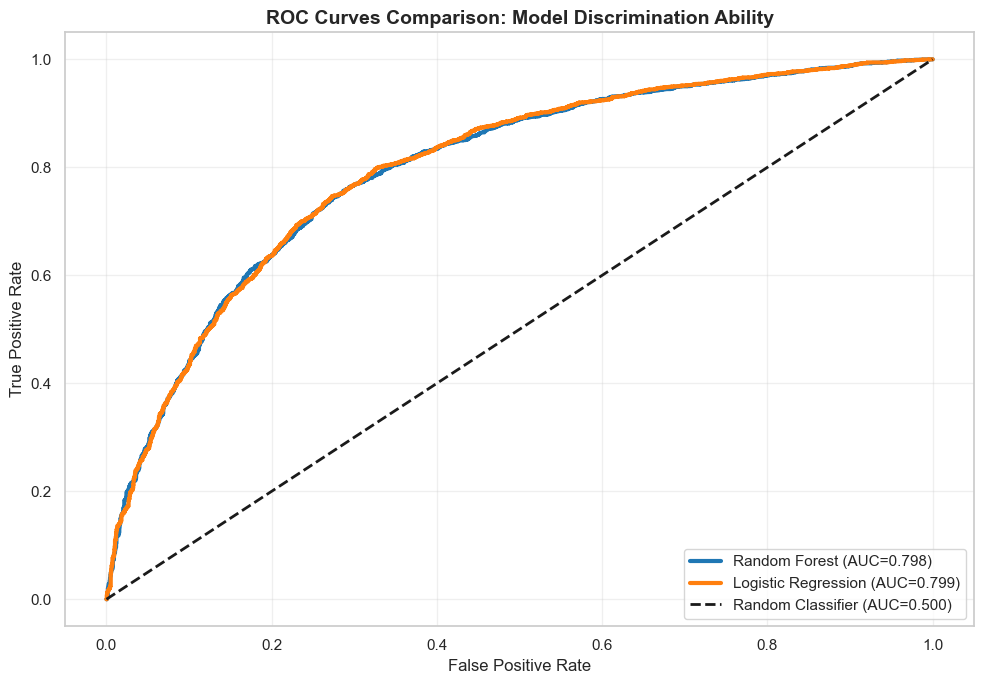

✓ Random Forest AUC:       0.7976
✓ Logistic Regression AUC: 0.7986


In [86]:
print("\n" + "="*80)
print("8.9 ROC CURVES COMPARISON")
print("="*80)

plt.figure(figsize=(10, 7))
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_test_proba)
fpr_lr, tpr_lr, _ = roc_curve(y_test, lr_test_proba)
rf_auc = auc(fpr_rf, tpr_rf)
lr_auc = auc(fpr_lr, tpr_lr)

plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC={rf_auc:.3f})', linewidth=3, color='#1f77b4')
plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC={lr_auc:.3f})', linewidth=3, color='#ff7f0e')
plt.plot([0, 1], [0, 1], 'k--', linewidth=2, label='Random Classifier (AUC=0.500)')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves Comparison: Model Discrimination Ability', fontweight='bold', fontsize=14)
plt.legend(loc='lower right', fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"✓ Random Forest AUC:       {rf_auc:.4f}")
print(f"✓ Logistic Regression AUC: {lr_auc:.4f}")


8.10 FEATURE IMPORTANCE - RANDOM FOREST (TOP 10)


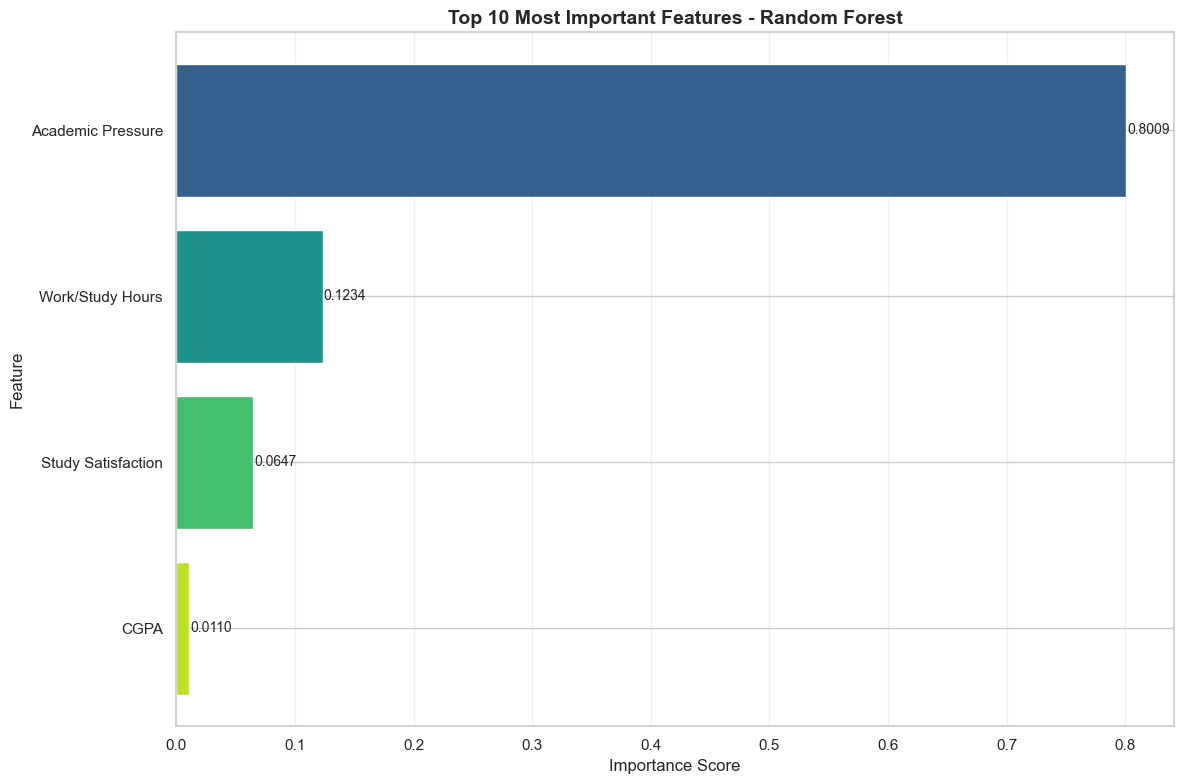

✓ Feature importance visualization complete!


In [87]:
print("\n" + "="*80)
print("8.10 FEATURE IMPORTANCE - RANDOM FOREST (TOP 10)")
print("="*80)

plt.figure(figsize=(12, 8))
top_10_features = rf_importance.head(10)
colors = plt.cm.viridis(np.linspace(0.3, 0.9, len(top_10_features)))
bars = plt.barh(range(len(top_10_features)), top_10_features['Importance'].values, color=colors)
plt.yticks(range(len(top_10_features)), top_10_features['Feature'].values, fontsize=11)
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.title('Top 10 Most Important Features - Random Forest', fontweight='bold', fontsize=14)
plt.gca().invert_yaxis()

# Add value labels on bars
for i, v in enumerate(top_10_features['Importance'].values):
    plt.text(v + 0.001, i, f'{v:.4f}', va='center', fontsize=10)

plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

print("✓ Feature importance visualization complete!")


8.7 PARTIAL DEPENDENCE ANALYSIS
✓ Plotting 4 features


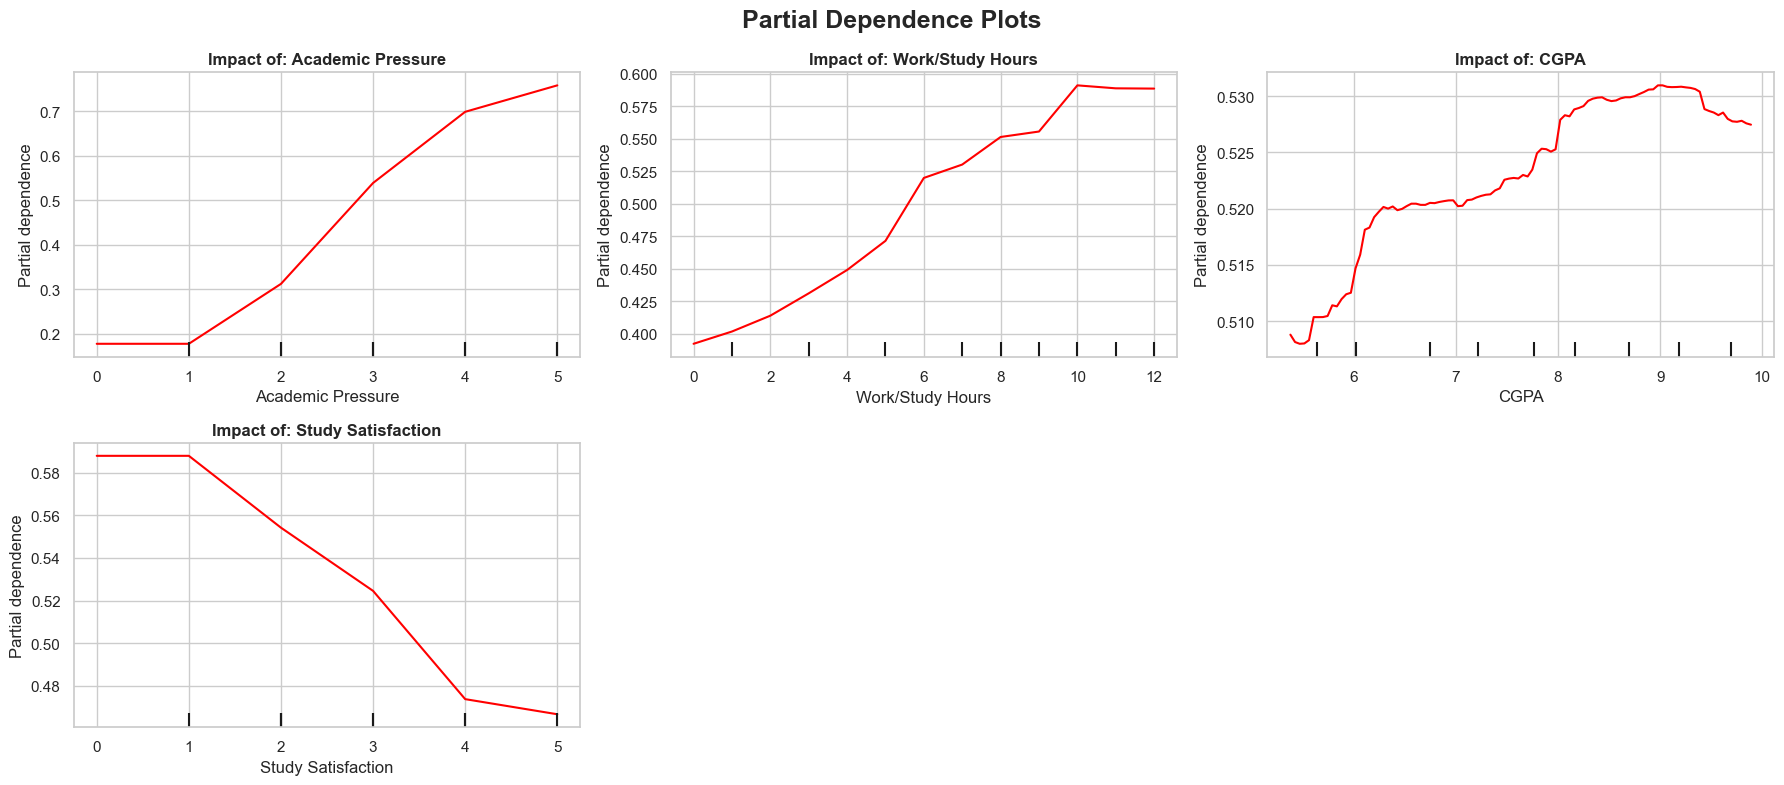

In [88]:
import matplotlib.pyplot as plt
from sklearn.inspection import PartialDependenceDisplay

print("\n" + "="*80)
print("8.7 PARTIAL DEPENDENCE ANALYSIS")
print("="*80)

X_pdp = X_train.copy()
for col in X_pdp.select_dtypes(include=['bool']).columns:
    X_pdp[col] = X_pdp[col].astype(int)

# Get all features with more than 2 unique values
numerical_only = [feat for feat in X_pdp.columns if X_pdp[feat].nunique() > 2]

print(f"✓ Plotting {len(numerical_only)} features")

n_cols = 3
n_rows = (len(numerical_only) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 4))
axes = axes.flatten()

for i, feature in enumerate(numerical_only):
    try:
        PartialDependenceDisplay.from_estimator(
            rf_model,
            X_pdp,
            features=[feature],
            ax=axes[i],
            kind='average',
            line_kw={"color": "red"}
        )
        axes[i].set_title(f"Impact of: {feature}", fontweight='bold')
    except Exception as e:
        axes[i].text(0.5, 0.5, f"Error: {feature}", ha='center', va='center', color='red')

# Hide unused subplots
for j in range(len(numerical_only), len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Partial Dependence Plots", fontsize=18, fontweight='bold')
plt.tight_layout()
plt.show()

### Explain the PDP
Interpretability: Partial Dependence Analysis (PDP)
In this section, we "open the black box" of the Random Forest model to understand how the most important features influence the probability of depression. Unlike linear models, Random Forest captures non-linear relationships and threshold effects.

1. Academic Pressure & Financial Stress (Threshold Effects)

Observation: Both features show a "step-up" pattern. The risk of depression remains relatively stable at low levels but surges significantly once the pressure/stress level crosses a certain threshold (typically level 2 or 3).

Insight: This suggests that students can cope with moderate stress, but there is a "breaking point" where the mental health risk increases drastically.

2. CGPA (The High-Achiever Paradox)

Observation: Interestingly, as CGPA increases, the probability of depression also tends to rise.

Insight: This reflects the "high-achiever" stress, where students with top grades often face immense self-imposed or external pressure to maintain their performance, making them more susceptible to anxiety and burnout.

3. Study Satisfaction (Protective Factors)

Observation: This features show a clear negative correlation (the curves go down).

Insight: Higher study satisfaction act as "protective shield." highlighting the vital importance of basic physiological factors.

4. Work/Study Hours (The Burden of Overwork)

Observation: The risk increases steadily as hours increase, with a steeper incline after 6–8 hours.

Insight: Excessive workload is a direct contributor to mental fatigue, confirming that long hours without adequate rest are a primary risk factor in this dataset.

Conclusion:
The model is not just looking at variables in isolation; it has learned that mental health is a result of complex, non-linear interactions. The most critical intervention points identified are managing academic pressure and ensuring adequate sleep.


8.11 LOGISTIC REGRESSION COEFFICIENTS (TOP RISK FACTORS)


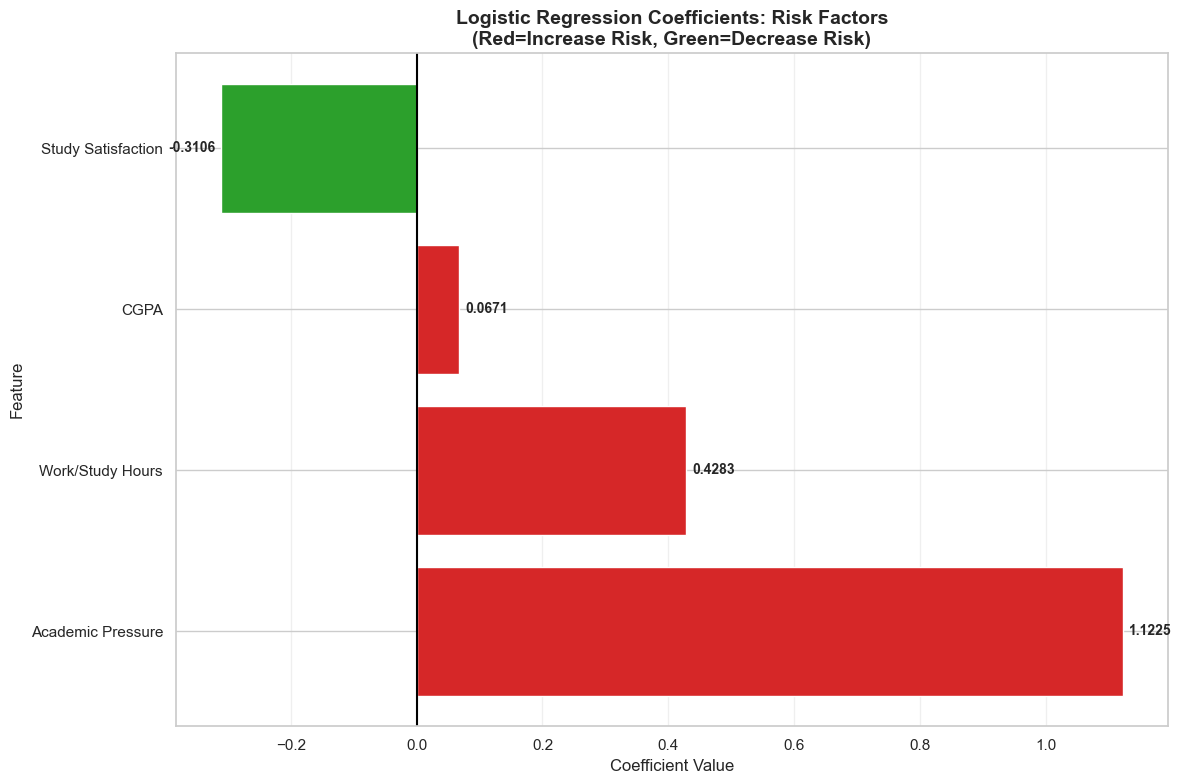

✓ Logistic Regression coefficients visualization complete!


In [89]:
print("\n" + "="*80)
print("8.11 LOGISTIC REGRESSION COEFFICIENTS (TOP RISK FACTORS)")
print("="*80)

plt.figure(figsize=(12, 8))
lr_coef_sorted = lr_coef.copy()
top_coef = pd.concat([lr_coef_sorted])
colors = ['#d62728' if x > 0 else '#2ca02c' for x in top_coef['Coefficient']]

bars = plt.barh(range(len(top_coef)), top_coef['Coefficient'].values, color=colors)
plt.yticks(range(len(top_coef)), top_coef['Feature'].values, fontsize=11)
plt.xlabel('Coefficient Value', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.title('Logistic Regression Coefficients: Risk Factors\n(Red=Increase Risk, Green=Decrease Risk)', fontweight='bold', fontsize=14)
plt.axvline(x=0, color='black', linestyle='-', linewidth=1.5)

# Add value labels on bars
for i, v in enumerate(top_coef['Coefficient'].values):
    plt.text(v + 0.01 if v > 0 else v - 0.01, i, f'{v:.4f}', va='center',
             ha='left' if v > 0 else 'right', fontsize=10, fontweight='bold')

plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

print("✓ Logistic Regression coefficients visualization complete!")


8.12 MODEL PERFORMANCE METRICS COMPARISON


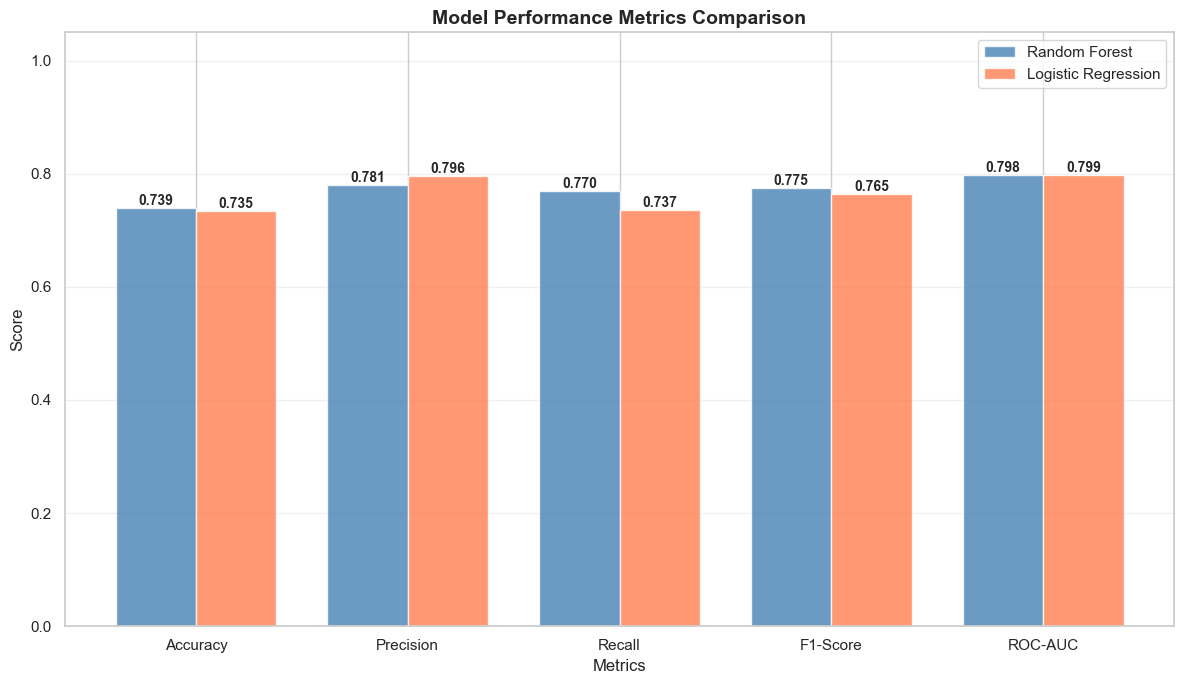


 DETAILED METRICS COMPARISON:
--------------------------------------------------------------------------------
Metric               Random Forest      Logistic Regression
--------------------------------------------------------------------------------
Accuracy             0.7388             0.7350            
Precision            0.7809             0.7957            
Recall               0.7699             0.7365            
F1-Score             0.7753             0.7650            
ROC-AUC              0.7976             0.7986            

✓ Performance comparison complete!


In [90]:
print("\n" + "="*80)
print("8.12 MODEL PERFORMANCE METRICS COMPARISON")
print("="*80)

plt.figure(figsize=(12, 7))

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
rf_scores = [
    accuracy_score(y_test, rf_test_pred),
    precision_score(y_test, rf_test_pred),
    recall_score(y_test, rf_test_pred),
    f1_score(y_test, rf_test_pred),
    auc(fpr_rf, tpr_rf)
]
lr_scores = [
    accuracy_score(y_test, lr_test_pred),
    precision_score(y_test, lr_test_pred),
    recall_score(y_test, lr_test_pred),
    f1_score(y_test, lr_test_pred),
    auc(fpr_lr, tpr_lr)
]

x = np.arange(len(metrics))
width = 0.38
bars1 = plt.bar(x - width/2, rf_scores, width, label='Random Forest', color='steelblue', alpha=0.8)
bars2 = plt.bar(x + width/2, lr_scores, width, label='Logistic Regression', color='coral', alpha=0.8)

plt.ylabel('Score', fontsize=12)
plt.xlabel('Metrics', fontsize=12)
plt.title('Model Performance Metrics Comparison', fontweight='bold', fontsize=14)
plt.xticks(x, metrics, fontsize=11)
plt.legend(fontsize=11)
plt.ylim([0, 1.05])
plt.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

# Print summary
print("\n DETAILED METRICS COMPARISON:")
print("-"*80)
print(f"{'Metric':<20} {'Random Forest':<18} {'Logistic Regression':<18}")
print("-"*80)
for i, metric in enumerate(metrics):
    print(f"{metric:<20} {rf_scores[i]:<18.4f} {lr_scores[i]:<18.4f}")

print("\n✓ Performance comparison complete!")

# Section 9: Risk Profiling & Student Segmentation

**Objective**: Segment students into risk groups based on depression prediction probability and analyze characteristics of each group.

**Risk Groups**:
- **HIGH RISK**: > 70% depression probability
- **MODERATE RISK**: 40-70% probability  
- **LOW RISK**: < 40% probability



9.1 RISK GROUP SEGMENTATION - Distribution & Characteristics


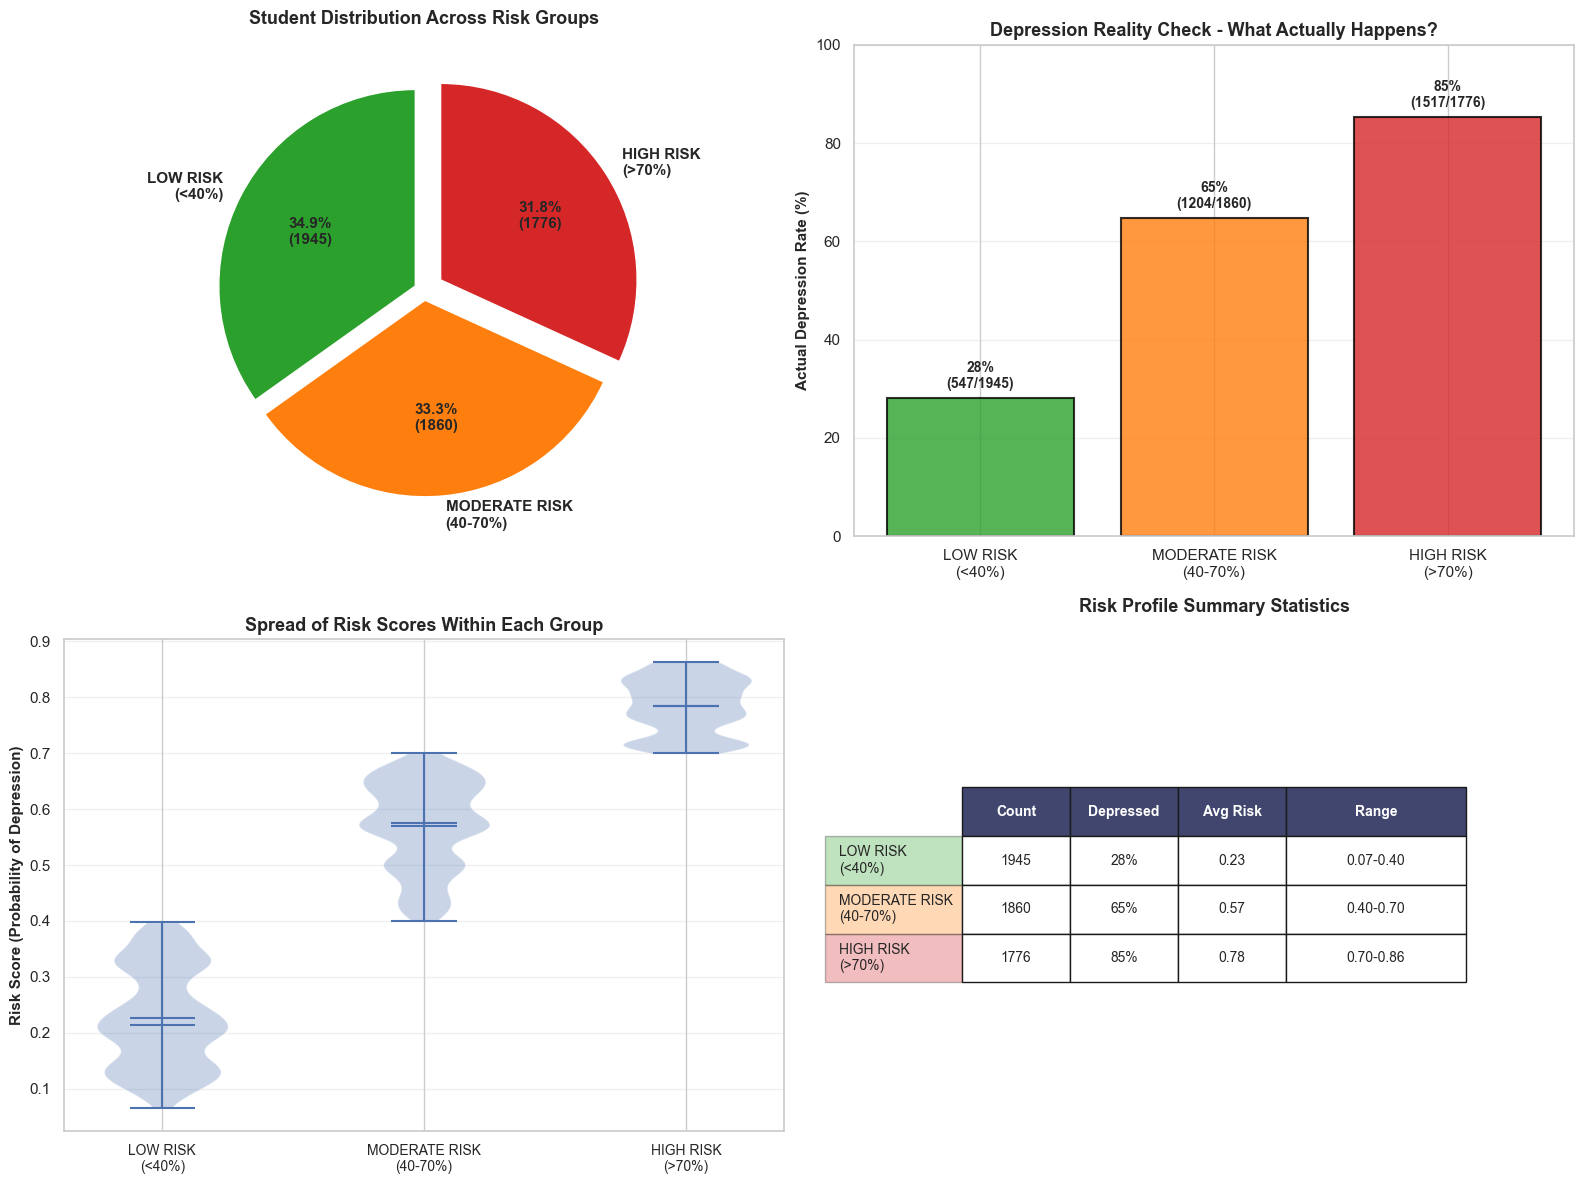


✓ Risk segmentation visualization complete!


In [91]:
print("\n" + "="*80)
print("9.1 RISK GROUP SEGMENTATION - Distribution & Characteristics")
print("="*80)

# Create risk segments based on RF prediction probability
risk_proba = rf_model.predict_proba(X_test)[:, 1]
risk_df = pd.DataFrame({
    'Risk_Score': risk_proba,
    'Actual_Depression': y_test.values
})

risk_df['Risk_Group'] = pd.cut(risk_df['Risk_Score'],
                                bins=[0, 0.40, 0.70, 1.0],
                                labels=['LOW RISK\n(<40%)', 'MODERATE RISK\n(40-70%)', 'HIGH RISK\n(>70%)'])

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Chart 1: Risk Group Distribution (Sunburst-style with counts)
group_counts = risk_df['Risk_Group'].value_counts().sort_index()
actual_depression = risk_df.groupby('Risk_Group')['Actual_Depression'].agg(['sum', 'count'])
actual_depression['rate'] = (actual_depression['sum'] / actual_depression['count'] * 100).round(1)

colors_risk = ['#2ca02c', '#ff7f0e', '#d62728']

# Custom autopct function to show percentage and count
def make_autopct(values):
    def my_autopct(pct):
        total = sum(values)
        val = int(round(pct*total/100.0))
        return f'{pct:.1f}%\n({val})'
    return my_autopct

wedges, texts, autotexts = axes[0, 0].pie(group_counts.values,
                                           labels=group_counts.index,
                                           autopct=make_autopct(group_counts.values),
                                           colors=colors_risk,
                                           startangle=90,
                                           textprops={'fontsize': 11, 'fontweight': 'bold'},
                                           explode=(0.05, 0.05, 0.1))
axes[0, 0].set_title('Student Distribution Across Risk Groups', fontsize=13, fontweight='bold', pad=15)

# Chart 2: Actual Depression Rate by Risk Group
bars = axes[0, 1].bar(range(len(actual_depression)), actual_depression['rate'].values,
                       color=colors_risk, alpha=0.8, edgecolor='black', linewidth=1.5)
axes[0, 1].set_xticks(range(len(actual_depression)))
axes[0, 1].set_xticklabels(actual_depression.index, fontsize=11)
axes[0, 1].set_ylabel('Actual Depression Rate (%)', fontsize=11, fontweight='bold')
axes[0, 1].set_title('Depression Reality Check - What Actually Happens?', fontsize=13, fontweight='bold')
axes[0, 1].set_ylim([0, 100])
axes[0, 1].grid(True, alpha=0.3, axis='y')

for i, (bar, val) in enumerate(zip(bars, actual_depression['rate'].values)):
    axes[0, 1].text(i, val + 2, f'{val:.0f}%\n({int(actual_depression["sum"].values[i])}/{int(actual_depression["count"].values[i])})',
                    ha='center', fontweight='bold', fontsize=10)

# Chart 3: Risk Score Distribution (Violin Plot)
risk_groups_order = ['LOW RISK\n(<40%)', 'MODERATE RISK\n(40-70%)', 'HIGH RISK\n(>70%)']
parts = axes[1, 0].violinplot([risk_df[risk_df['Risk_Group'] == group]['Risk_Score'].values
                               for group in risk_groups_order],
                              positions=range(len(risk_groups_order)),
                              showmeans=True, showmedians=True)
axes[1, 0].set_xticks(range(len(risk_groups_order)))
axes[1, 0].set_xticklabels(risk_groups_order, fontsize=10)
axes[1, 0].set_ylabel('Risk Score (Probability of Depression)', fontsize=11, fontweight='bold')
axes[1, 0].set_title('Spread of Risk Scores Within Each Group', fontsize=13, fontweight='bold')
axes[1, 0].grid(True, alpha=0.3, axis='y')

# Chart 4: Summary Table as Heatmap
summary_stats = []
for group in risk_groups_order:
    group_data = risk_df[risk_df['Risk_Group'] == group]
    summary_stats.append([
        len(group_data),
        f"{group_data['Actual_Depression'].mean()*100:.0f}%",
        f"{group_data['Risk_Score'].mean():.2f}",
        f"{group_data['Risk_Score'].min():.2f}-{group_data['Risk_Score'].max():.2f}"
    ])

summary_table = pd.DataFrame(summary_stats,
                             columns=['Count', 'Depressed', 'Avg Risk', 'Range'],
                             index=risk_groups_order)

axes[1, 1].axis('tight')
axes[1, 1].axis('off')
table = axes[1, 1].table(cellText=summary_table.values,
                         colLabels=summary_table.columns,
                         rowLabels=summary_table.index,
                         cellLoc='center',
                         loc='center',
                         colWidths=[0.15, 0.15, 0.15, 0.25])
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 2.5)

# Color header
for i in range(len(summary_table.columns)):
    table[(0, i)].set_facecolor('#40466e')
    table[(0, i)].set_text_props(weight='bold', color='white')

# Color rows by risk
for i, color in enumerate(colors_risk):
    table[(i+1, -1)].set_facecolor(color)
    table[(i+1, -1)].set_alpha(0.3)

axes[1, 1].set_title('Risk Profile Summary Statistics', fontsize=13, fontweight='bold', pad=20)

plt.tight_layout()
plt.show()

print("\n✓ Risk segmentation visualization complete!")


9.2 RISK GROUP PROFILES - How Different Are They?


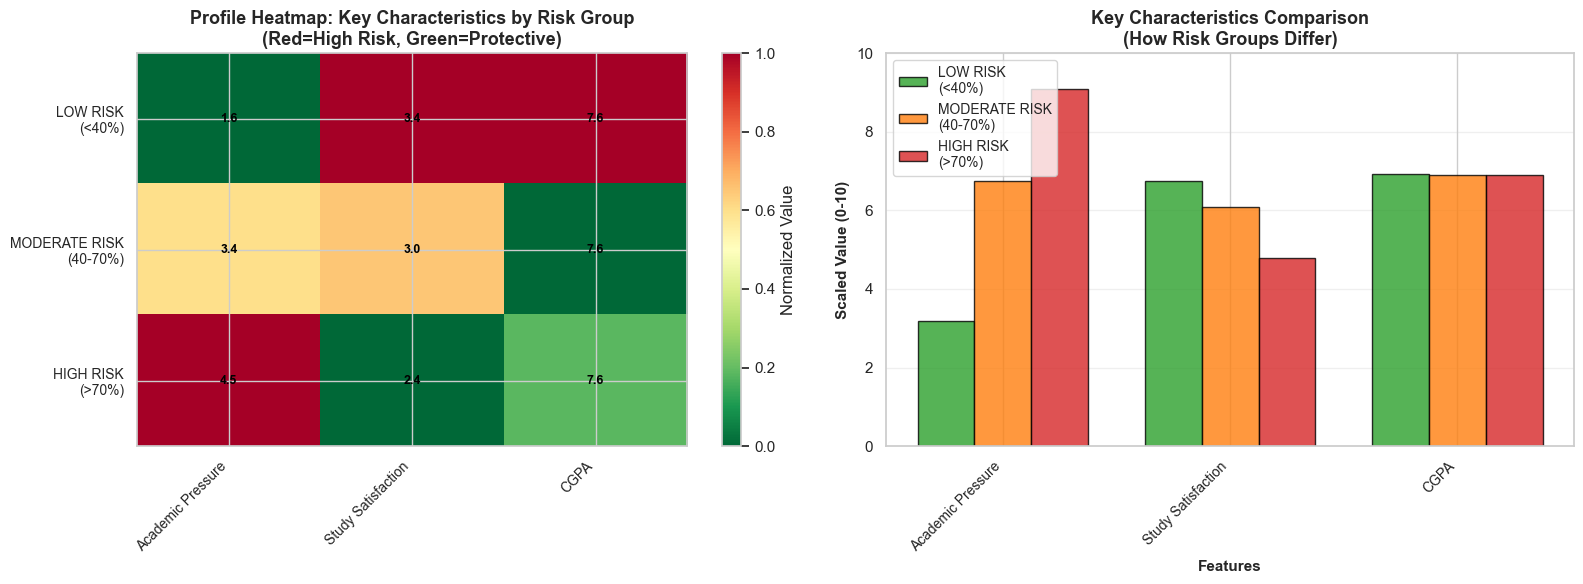


📊 DETAILED RISK GROUP PROFILES:

LOW RISK
(<40%)
----------------------------------------------------------------------------------------------------
  Students: 1945 | Depressed: 547 (28%)
  Academic Pressure             1.60
  Study Satisfaction            3.38
  CGPA                          7.65

MODERATE RISK
(40-70%)
----------------------------------------------------------------------------------------------------
  Students: 1860 | Depressed: 1204 (65%)
  Academic Pressure             3.37
  Study Satisfaction            3.04
  CGPA                          7.63

HIGH RISK
(>70%)
----------------------------------------------------------------------------------------------------
  Students: 1776 | Depressed: 1517 (85%)
  Academic Pressure             4.55
  Study Satisfaction            2.40
  CGPA                          7.63

✓ Risk profile analysis complete!


In [92]:
print("\n" + "="*80)
print("9.2 RISK GROUP PROFILES - How Different Are They?")
print("="*80)

# Add risk group info to test data for analysis
X_test_with_risk = X_test.copy()
X_test_with_risk['Risk_Group'] = risk_df['Risk_Group'].values
X_test_with_risk['Actual_Depression'] = risk_df['Actual_Depression'].values

# Select key features for profile comparison
key_features = ['Age', 'Academic Pressure', 'Financial Stress', 'Sleep Duration',
                'Study Satisfaction', 'CGPA', 'Work Study Hours']

# Make sure all features exist
available_features = [f for f in key_features if f in X_test.columns]

# Prepare profile data
profile_data = []
risk_groups_order = ['LOW RISK\n(<40%)', 'MODERATE RISK\n(40-70%)', 'HIGH RISK\n(>70%)']

for group in risk_groups_order:
    group_subset = X_test_with_risk[X_test_with_risk['Risk_Group'] == group]
    profile = []
    for feat in available_features:
        avg_val = group_subset[feat].mean()
        profile.append(avg_val)
    profile_data.append(profile)

profile_df = pd.DataFrame(profile_data,
                          columns=available_features,
                          index=risk_groups_order)

# Normalize for heatmap (0-1 scale within each feature)
profile_normalized = profile_df.copy()
for col in profile_normalized.columns:
    min_val = profile_df[col].min()
    max_val = profile_df[col].max()
    profile_normalized[col] = (profile_df[col] - min_val) / (max_val - min_val) if max_val > min_val else 0

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Chart 1: Heatmap of characteristics by risk group
im = axes[0].imshow(profile_normalized.values, cmap='RdYlGn_r', aspect='auto', vmin=0, vmax=1)
axes[0].set_xticks(range(len(available_features)))
axes[0].set_yticks(range(len(risk_groups_order)))
axes[0].set_xticklabels(available_features, rotation=45, ha='right', fontsize=10)
axes[0].set_yticklabels(risk_groups_order, fontsize=10)
axes[0].set_title('Profile Heatmap: Key Characteristics by Risk Group\n(Red=High Risk, Green=Protective)',
                  fontsize=13, fontweight='bold')

# Add value labels
for i in range(len(risk_groups_order)):
    for j in range(len(available_features)):
        text = axes[0].text(j, i, f'{profile_df.iloc[i, j]:.1f}',
                           ha="center", va="center", color="black", fontweight='bold', fontsize=9)

# Color bar
cbar = plt.colorbar(im, ax=axes[0], label='Normalized Value')

# Chart 2: Radar-style comparison using grouped bar chart
x_pos = np.arange(len(available_features))
width = 0.25
colors_risk = ['#2ca02c', '#ff7f0e', '#d62728']

# Normalize each feature to 0-10 scale for better visualization
for ax in [axes[1]]:
    for i, group in enumerate(risk_groups_order):
        group_subset = X_test_with_risk[X_test_with_risk['Risk_Group'] == group]
        values = []
        for feat in available_features:
            val = group_subset[feat].mean()
            # Scale to 0-10
            min_v = X_test[feat].min()
            max_v = X_test[feat].max()
            scaled = (val - min_v) / (max_v - min_v) * 10 if max_v > min_v else 5
            values.append(scaled)

        ax.bar(x_pos + (i-1)*width, values, width, label=group,
               color=colors_risk[i], alpha=0.8, edgecolor='black', linewidth=1)

axes[1].set_xlabel('Features', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Scaled Value (0-10)', fontsize=11, fontweight='bold')
axes[1].set_title('Key Characteristics Comparison\n(How Risk Groups Differ)', fontsize=13, fontweight='bold')
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(available_features, rotation=45, ha='right', fontsize=10)
axes[1].legend(loc='upper left', fontsize=10)
axes[1].grid(True, alpha=0.3, axis='y')
axes[1].set_ylim([0, 10])

plt.tight_layout()
plt.show()

# Print detailed characteristics
print("\n📊 DETAILED RISK GROUP PROFILES:")
print("="*100)
for i, group in enumerate(risk_groups_order):
    group_subset = X_test_with_risk[X_test_with_risk['Risk_Group'] == group]
    print(f"\n{group}")
    print("-"*100)
    print(f"  Students: {len(group_subset)} | Depressed: {group_subset['Actual_Depression'].sum()} ({group_subset['Actual_Depression'].mean()*100:.0f}%)")
    for feat in available_features:
        avg = group_subset[feat].mean()
        print(f"  {feat:<25} {avg:>8.2f}")

print("\n✓ Risk profile analysis complete!")

In [ ]:
from joblib import dump, load
import os

save_dir = r"C:\Users\samak\Desktop\Machinelearning project\Student_depression\ml-project\backend\saved_models"
os.makedirs(save_dir, exist_ok=True)

model_path = os.path.join(save_dir, "model_a.pkl")

# Save the model
dump(rf_model, model_path)

print(f"✓ Model A saved at: {model_path}")

# Optional: test loading
rf_model_loaded = load(model_path)
print("✓ Model loaded successfully")